# Dependencies

In [ ]:
from langchain_community.document_loaders import PyPDFLoader
from pathlib import Path
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_experimental.text_splitter import SemanticChunker
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_core.tools import tool

from langchain_core.messages import BaseMessage 
# The foundational class for all message types in LangGraph

from langchain_core.messages import ToolMessage
# Data that's passed back to the LLM after the tool has been called such the content and tool_call_id

from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
# Message to provide instructions to LLM

from langgraph.graph.message import add_messages

from typing import Annotated, Sequence, TypedDict, Literal, List

from langgraph.graph import StateGraph

from dotenv import load_dotenv, find_dotenv

from langchain_groq import ChatGroq #using Groq llm.

from sklearn.metrics.pairwise import cosine_similarity

from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import ToolNode

from sentence_transformers import CrossEncoder  

import re

from langgraph.checkpoint.sqlite import SqliteSaver
import uuid

In [ ]:
load_dotenv()

In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()

# AgentState

In [ ]:
class AgentState(TypedDict):
    messages : Annotated[Sequence[BaseMessage],add_messages]
    retrieval : Literal["RAG", "WEB", "RAG & WEB"]
    route : Literal["GENERIC", "RESEARCH"]
    web_retrieved_info : List[dict]
    good_retrieved_rag_info : List[dict]
    weak_retrieved_rag_info : List[dict]
    resolved_query: str

# Loading docs

In [ ]:
pdf_folder = Path(r"D:\LangGraph_portfolio_project\LangGraph_project_pdf_data")

In [ ]:
all_docs = []

for pdf_file in pdf_folder.glob("*.pdf"): # Find every file in this folder whose extension is .pdf
    print(f"Loading: {pdf_file.name}")

    loader = PyPDFLoader(str(pdf_file))
    documents = loader.load()

    all_docs.extend(documents) # combines the pages from every paper into one list.

# Chunking

In [ ]:
# Choosing the Right Splitter

# Standard text / Prose => RecursiveCharacterTextSplitter
# Strict LLM Token Limits => TokenTextSplitter
# Code Repositories => Language.from_documents()
# Web Scraping / Webpages => HTMLHeaderTextSplitter
# Complex text needing deep context => SemanticChunker

# Let's try semantic chunking and then use recursive character splitter. Why?
# In a notebook/demo, you can get away with just SemanticChunker.
# In production, one oversized chunk can crash your pipeline or silently degrade retrieval — and it will happen eventually on some document.
# The post-processing step makes the pipeline robust to that: it can't produce a chunk that breaks your downstream embedding call or LLM prompt.

In [ ]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

In [ ]:
semantic_splitter = SemanticChunker(
    embeddings, # We could only perform semantic chunking once we embed, because that's when we would know similarity score between different phrases/sentences.
    breakpoint_threshold_type="percentile",  # options: "percentile", "standard_deviation", "interquartile", "gradient"
    breakpoint_threshold_amount=90,          # higher = fewer, larger chunks

)

semantic_chunks = semantic_splitter.split_documents(all_docs)

In [ ]:
print(len(semantic_chunks))
print(semantic_chunks[120].page_content)
print(semantic_chunks[120].metadata)


In [ ]:
large_chunks = [
    chunk for chunk in semantic_chunks
    if len(chunk.page_content) > 1000
]

# print("Chunks > 1000:", len(large_chunks))

# print("Average final chunk size:",sum(len(c.page_content) for c in semantic_chunks) / len(semantic_chunks))

# print("Min:", min(len(c.page_content) for c in semantic_chunks))
# print("Max:", max(len(c.page_content) for c in semantic_chunks))

In [ ]:
tiny_chunks = [
    chunk for chunk in semantic_chunks
    if len(chunk.page_content.strip()) < 30
]

print("Tiny chunks:", len(tiny_chunks))

# for chunk in tiny_chunks:
#     print("-----")
#     print(repr(chunk.page_content))
#     print(chunk.metadata)

In [ ]:
final_chunks = [
    chunk
    for chunk in semantic_chunks
    if len(chunk.page_content.strip()) >= 30
] # removing chunks the tiny chunks since they produce no context. 

In [ ]:
for i, chunk in enumerate(final_chunks):
    chunk.metadata["chunk_id"] = f"semantic_chunk_{i+1}" # reassigning chunks after filtering out tiny chunks.

In [ ]:
# print(final_chunks[0].metadata["chunk_id"])
# print(final_chunks[-1].metadata["chunk_id"])
# print(len(final_chunks))

# print(final_chunks[0].page_content,'\n')
# print(final_chunks[-1].page_content)

In [ ]:
# lengths = [len(chunk.page_content.strip()) for chunk in final_chunks]

# print("Final chunks:", len(final_chunks))
# print("Average:", sum(lengths) / len(lengths))
# print("Min:", min(lengths))
# print("Max:", max(lengths))

# Creating a vector DB

In [ ]:
# Creating a vector DB based on semantic chunks.
import shutil
import os

chroma_path = r"D:\LangGraph_portfolio_project\ChromaDB"

if os.path.exists(chroma_path):
    shutil.rmtree(chroma_path)

semantic_db = Chroma.from_documents(
    documents=final_chunks,
    embedding=embeddings,
    collection_name="semantic_final_chunks",
    persist_directory=chroma_path
)

In [ ]:
print("Expected:", len(final_chunks))
print("Stored:", semantic_db._collection.count())

# Building a WEB retriever

In [ ]:
%pip install -U langchain-tavily

In [ ]:
from langchain_tavily import TavilySearch # Using tavily to retrieve data for our LLM. (Check : what is tavily? and why do we use it?)

In [ ]:
web_search = TavilySearch(
    max_results=5,
    search_depth='advanced',
    topic='general'
)

# we could add more parameters like "include_domains","exlude_domains","include_raw_content","include_answer", etc.

# LLM agent

In [ ]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

# Cross encoder

In [ ]:
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

# Query maker

In [ ]:
def query_maker(state: AgentState) -> AgentState:
    '''Node to collect the user query'''
    return state


# LLM router

In [ ]:
system_prompt_route = '''
You are a routing agent.

Analyze the user's query and decide what the graph should do next.

Return RESEARCH if the question is related to AI, Machine Learning,
Deep Learning, Data Science, Statistics in AI/ML/DL or a topic covered by the provided AI/ML research papers.

Return GENERIC if the question is unrelated to AI, Machine Learning,
Deep Learning, and is not relevant to the provided research papers.

If you're unclear return RESEARCH.

Eg question and how to classify them:
q1) What is backpropogation? → RESEARCH

q2) What is the best hangout in Chennai → GENERIC

q3) Explain gradient descent in machine learning. → RESEARCH

q4) Top restaurants to try in Bangalore. → GENERIC

q5) How does convolution work in CNNs? → RESEARCH

Return ONLY one of these two words in UPPERCASE, no punctuation, no explanation :

RESEARCH

GENERIC
'''

In [ ]:
def llm_call_for_route(state : AgentState) -> AgentState:
    '''
    Node for the llm agent to determine if the user query is generic or based on some research in AI for it to determine it's next aciton.
    '''
    messages = list(state['messages'])
    messages = [SystemMessage(content=system_prompt_route)] + messages
    response = llm.invoke(messages)

    if not response or not hasattr(response, "content"):
        print("LLM returned no content, setting route as EMPTY...\n")
        route = ""
    else:
        route = str(response.content).strip().upper()
    
    valid_routes = {"GENERIC", "RESEARCH"}

    if route not in valid_routes: # Just in case the LLM agent doesn't know what route to choose.
        
        LLM_router_count = 0

        while(True): # A loop for the agent to get the right route just in case it generates invalid route.
            LLM_router_count += 1

            print("THE RESPONSE IS NEITHER GENERIC OR RESEARCH FROM THE LLM OR BACK TO QUERY MAKER...\n")
            response = llm.invoke(messages)

            if not response or not hasattr(response, "content"):
                route = ""
            else:
                route = str(response.content).strip().upper()
                
            print("THE LLM RETRYING FOR A VALID ROUTE...\n")

            if route == "GENERIC" or  route == "RESEARCH":
                print(f"THE RESPONSE IS {route} FROM THE LLM FOR A VALID ROUTE...")
                break

            if LLM_router_count > 4: # Setting the maximum number of retry's to be 5.
                print("THE LLM COULDN'T FIND A VALID ROUTE SO ROUTE IS SET AS RESEARCH BY DEFAULT...\n")
                route = "RESEARCH"
                break
        
    state["route"] = route

    return state
    


# Conditional routing function

In [ ]:
def continue_routing_between_generic_and_research(state : AgentState):
    '''To route between Generic and Research...'''
    if state['route'] == "GENERIC":
        return "generic_edge"
    elif state["route"] == "RESEARCH":
        return "query_analyzer_edge"
    else: # A fall back condition just in case any other state get's into state['route']
        print(f"Unexpected route: {state['route']}, defaulting to generic_edge")
        return "generic_edge"

# Generic node

In [ ]:
def generic_node(state : AgentState):
    '''Node for generic response...'''
    try:
        # Guard against empty messages
        if 'messages' not in state or not state['messages']:
            state["messages"] = [HumanMessage(content="No query provided.")]
        last_message = state['messages'][-1]

        # Ensure we pass the right type to llm.invoke
        # isinstance(last_message, str) => checks if last_message is a plain Python string.
        # if not string, wrap it in a list, because many LLM APIs expect a list of messages
        response = llm.invoke([last_message]) if not isinstance(last_message, str) else llm.invoke(last_message)

        # Append only if response is valid
        if response and hasattr(response, "content"):
            state["messages"].append(response)
        else:
            state["messages"].append(AIMessage(content="Sorry, I couldn't generate a response."))

    except Exception as e:
        print(f"Error in generic_node: {e}")
        state["messages"].append(AIMessage(content="An error occurred while generating a response."))

    return state

# Building a query analyzer and determining what kind of retrieval by using retrieval part of RAG, based on the quality and relevance of the chunks retrieved.

So effectively we have already done retrieval part of rag and there is no need for a file retriever tool but rather it's about choosing web tool or web and rag tool.

A function to check if a chunk from RAG is good or not -> Used by query analyzer node.

# Filters for query analyzer

In [ ]:
from collections import Counter

def is_good_chunk(text):
    '''Funtion to check if a given chunk is of any value/ relevance for the LLM to frame an answer. Used by query analyzer node...'''
    words = text.split()

    # Too short (Checking if the chunks are too small to provide any context.)
    if len(words) < 30:
        return False

    # Check amount of normal textual content (Contains words that have alphabet in the current chunk of words.)
    alpha_words = [
        word for word in words
        if any(char.isalpha() for char in word) 
    ]

    if len(alpha_words) / len(words) < 0.6: # Checking the ratio of words with alphabets and the actual number of words
        return False # returns False, hence the chunk isn't a good chunk.

    # Detect excessive repetition
    word_counts = Counter(word.lower() for word in words) # Counter to check how much counts each word have in the chunk

    most_common_word, count = word_counts.most_common(1)[0] # Find the word that appears the most, and tell me how many times it appears.

    repetition_ratio = count / len(words)  

    if repetition_ratio > 0.20: # If the most appeared word is 20% of the words in the chunk then it's not a good chunk
        return False

    return True

In [ ]:
def looks_like_author_line(line):

    pattern = r"""
        ^[A-Z][A-Za-z'’-]+
        ,
        \s*
        (?:[A-Z]\.?){1,3}
        (?:\s*,|\s+and\s+|\s*&\s*)
    """

    return bool(re.search(pattern, line.strip(), re.VERBOSE))

In [ ]:
def is_bibliography_chunk(text):

    text = text.strip()

    if not text:
        return False

    lines = [
        line.strip()
        for line in text.splitlines()
        if line.strip()
    ]

    if len(lines) < 2:
        return False

    text_lower = text.lower()

    # Explicit bibliography/reference heading
    bibliography_headings = [
        "references",
        "bibliography",
        "works cited",
        "literature cited",
        "references and notes"
    ]

    first_lines = "\n".join(lines[:5]).lower()

    for heading in bibliography_headings:
        if heading in first_lines:
            return True

    # 2. Citation signals
    citation_patterns = [
        r"\[\d+\]",              # [1], [23]
        r"\bet al\.",            # et al.
        r"\bdoi\b",              # DOI
        r"\barxiv\b",            # arXiv
        r"https?://",            # URLs
    ]

    citation_count = sum(
        len(re.findall(pattern, text_lower))
        for pattern in citation_patterns
    )

    # 3. Author-name detection
    author_like_lines = sum(
        looks_like_author_line(line)
        for line in lines
    )

    author_ratio = author_like_lines / len(lines)

    # 4. Bibliography decision
    if author_ratio >= 0.4 and citation_count >= 2:
        return True

    # 5. Numbered reference entries
    numbered_references = sum(
        bool(re.match(r"^\[\d+\]", line))
        for line in lines
    )

    if numbered_references >= 2:
        return True

    return False

# Query analyzer node

In [ ]:
def query_analyzer_node(state: AgentState) -> AgentState:
    """
    Query analysis + retrieval + reranking + routing decision.
    """

    # =========================================================
    # GET LATEST USER MESSAGE
    # =========================================================

    current_message = state["messages"][-1]

    if not isinstance(current_message, HumanMessage):
        return state

    conversation = state["messages"][-5:] # To get context, If needed.

    conversation_text = "\n".join(
        f"{type(msg).__name__}: {msg.content}"
        for msg in conversation
    )

    # =========================================================
    # QUERY RESOLUTION (CONTEXT HANDLING)
    # =========================================================

    resolve_prompt = f"""
    You are a conversation query resolver.

    Conversation:
    {conversation_text}

    Latest user message:
    {current_message.content}

    Convert into a standalone research question.
    Do NOT answer it.
    Return only the rewritten question.
    """

    try:
        resolved_question = llm.invoke(resolve_prompt).content.strip() # Using LLM to make a resolved prompt based on previous convo.
    except Exception:
        resolved_question = current_message.content

    state["resolved_query"] = resolved_question

    # =========================================================
    # QUERY EXPANSION
    # =========================================================

    expansion_prompt = f"""
    Expand the query for semantic retrieval.

    Question:
    {resolved_question}

    Return up to 5 keywords (comma separated).
    """

    try:
        keyword_output = llm.invoke(expansion_prompt).content # expanding the query with relative key words.
        keywords = [
            k.strip()
            for k in keyword_output.split(",")
            if k.strip()
        ][:3]

        expanded_query = resolved_question + " " + " ".join(keywords)

    except Exception:
        expanded_query = resolved_question

    # =========================================================
    # MMR RETRIEVAL
    # =========================================================

    try:
        results = semantic_db.max_marginal_relevance_search(
            expanded_query,
            k=20,
            fetch_k=60,
            lambda_mult=0.85
        )

    except Exception:
        state["retrieval"] = "WEB"
        return state

    if not results:
        state["retrieval"] = "WEB"
        return state

    # =========================================================
    # FILTER NON-USEFUL CHUNKS
    # =========================================================

    results = [
        doc for doc in results
        if not is_bibliography_chunk(doc.page_content)
    ]

    if not results:
        state["retrieval"] = "WEB"
        return state

    # =========================================================
    # RERANKING (CROSS ENCODER)
    # =========================================================

    try:
        pairs = [(resolved_question, doc.page_content) for doc in results]
        rerank_scores = reranker.predict(pairs)

    except Exception:
        state["retrieval"] = "WEB"
        return state

    # =========================================================
    # DUAL SCORING (RERANK + SEMANTIC SIMILARITY)
    # =========================================================

    query_emb = embeddings.embed_query(resolved_question)

    doc_embs = [
        embeddings.embed_documents([doc.page_content])[0]
        for doc in results
    ]

    sim_scores = [
        cosine_similarity([query_emb], [d])[0][0]
        for d in doc_embs
    ]

    # ---------------------------------------------------------
    # normalize
    # ---------------------------------------------------------

    def normalize(x):
        mn, mx = min(x), max(x)
        return [(i - mn) / (mx - mn + 1e-8) for i in x]

    norm_rerank = normalize(rerank_scores)
    norm_sim = normalize(sim_scores)

    # =========================================================
    # 7. FINAL SCORING
    # =========================================================

    ALPHA = 0.7  # reranker weight
    BETA = 0.3   # similarity weight

    final_scores = [
        ALPHA * r + BETA * s
        for r, s in zip(norm_rerank, norm_sim)
    ]

    reranked_results = sorted(
        zip(final_scores, results),
        key=lambda x: x[0],
        reverse=True
    )

    final_results = reranked_results[:10]

    # =========================================================
    # BUILD RAG STORE
    # =========================================================

    state["good_retrieved_rag_info"] = []
    state["weak_retrieved_rag_info"] = []

    STRONG_THRESHOLD = 0.7
    WEAK_THRESHOLD = 0.4

    strong_chunks = 0
    weak_chunks = 0

    for score, doc in final_results:

        entry = {
            "Source": doc.metadata.get("source"),
            "Chunk ID": doc.metadata.get("chunk_id"),
            "Content": doc.page_content,
            "Score": float(score)
        }

        if score >= STRONG_THRESHOLD:
            state["good_retrieved_rag_info"].append(entry)
            strong_chunks += 1

        elif score >= WEAK_THRESHOLD:
            state["weak_retrieved_rag_info"].append(entry)
            weak_chunks += 1

    # =========================================================
    # ROUTING DECISION
    # =========================================================

    if strong_chunks >= 5:
        state["retrieval"] = "RAG"

    elif weak_chunks >= 2:
        state["retrieval"] = "RAG" #"RAG_AND_WEB"

    else:
        state["retrieval"] = "RAG" #"WEB"

    return state

# Retrieval router node
Router node for the type of retrieval we need to do based on our query analyzer.

In [ ]:
def retrieval_router_node(state : AgentState) -> AgentState:
    return state

In [ ]:
def retrieval_router_function(state : AgentState):
    '''Routes between RAG generation/ WEB generation/ RAG and WEB generation'''
    if state['retrieval'] == "RAG":
        return "RAG_edge"
    else:
        return "WEB_retriever_edge"

# RAG generation

In [ ]:
def rag_node(state : AgentState) -> AgentState:
    '''Node for RAG generation...'''
    if isinstance(state['messages'][-1], HumanMessage):
        user_question = state["resolved_query"].strip()
        
        if not user_question:
            state["messages"].append(AIMessage(content="No question provided."))
            return state
        
        rag_results = state.get("good_retrieved_rag_info", [])

        if not rag_results or not isinstance(rag_results, list):
            state["messages"].append(AIMessage(content="No RAG context available."))
            return state
        
        # Build context parts
        context_parts = []
        for item in rag_results:
            source = item.get("Source", "Unknown")
            chunk_id = item.get("Chunk ID", "Unknown")
            content = item.get("Content", "")
            snippet = (content)#[:1000] + "...") if len(content) > 1000 else content
            context_parts.append(f"Source: {source}\nChunk ID: {chunk_id}\nContent: {snippet}")

        context = "\n\n".join(context_parts)

        prompt = f"""
        Answer the user's question using the provided research context.

        User question:
        {user_question}

        Research context:
        {context}

        When using information from the research context,
        cite the Source and Chunk ID that support your answer.

        Once you retrieve the context generate it under,
        RESEARCH PAPER EVIDENCE:

        If the research context does not contain enough information to answer,
        say that the context is insufficient. Do not invent information.
        At the end, generate ONE concise follow-up question.
        The follow-up question must be directly related to the user's question.
        It should help the user explore the topic further.
        Do not answer the follow-up question.
        Do not generate multiple follow-up questions.
        """

        try:
            response = llm.invoke(prompt)
            if not response or not hasattr(response, "content"):
                state["messages"].append(AIMessage(content="Sorry, I couldn't generate a response."))
            else:
                if isinstance(response, AIMessage): # Conditions to avoid double wrapping AIMessage just in case.
                    state["messages"].append(response)
                elif response and hasattr(response, "content"):
                    state["messages"].append(AIMessage(content=response.content))

        except Exception as e:
            print(f"Error in rag_node, and the exception is : {e}")
            state["messages"].append(AIMessage(content="An error occurred while generating a response."))

    return state

# Web retriever

In [ ]:
def web_retriever_node(state : AgentState) -> AgentState:
    '''
    Search the web and retrieve information relevant to the user's query. 
    '''
    user_query = state["resolved_query"].strip()

    if not user_query:
        state['web_retrieved_info'] = "Empty query provided. Defaulting to WEB retrieval."
        return state

    try:
        results = web_search.invoke(user_query)
    except Exception as e:
        state['web_retrieved_info'] = f"Web search failed, and the type of exception is : {e}"
        return state

    formatted_results = []

    # Defensive check: only loop if results is a dict
    if isinstance(results, dict):
        for result in results.get("results", []): # safely retrieves the list of search results. If "results" doesn’t exist, it defaults to an empty list, so the loop won’t crash.
            title = result.get("title", "Untitled") # tries to grab the title. If it’s missing, it uses "Untitled" as a fallback.
            url = result.get("url", "No URL") # ensures you always have a URL string, even if the API didn’t provide one.
            content = result.get("content", "") # pulls the body text of the result. If missing, it defaults to an empty string.
            snippet = (content)#[:1500] + "...") if len(content) > 1500 else content # If the content is longer than 1500 characters, it truncates it to the first 1500 and adds "..." to indicate more text exists. If shorter, it just keeps the whole content.

            formatted_results.append({ # Each result is appended as a dictionary with three keys: "title", "url", and "snippet".
                "title": title,
                "url": url,
                "snippet": snippet
            })
            
    else:
        state['web_retrieved_info'] = "Unexpected search results format."
        return state

    state['web_retrieved_info'] = formatted_results if formatted_results else "No relevant web results found."
    return state

# Web and Web-RAG router

In [ ]:
def web_and_webrag_router_node(state : AgentState) -> AgentState:
    return state

In [ ]:
def web_and_webrag_router_condition(state : AgentState):

    retrieval = state.get("retrieval", "").strip().upper()

    if(retrieval == "WEB"):
        return "WEB_generation_edge"
    elif(retrieval == "RAG_AND_WEB"):
        return "RAG_AND_WEB_generation_edge"
    else:
        print(f"Unexpected retrieval mode: {retrieval}, defaulting to RAG+WEB")
        return "RAG_AND_WEB_generation_edge"

# Web generation

In [ ]:
def web_generation_node(state : AgentState) -> AgentState:
    '''Generate response based on retrieved info from the net...'''

    user_question = state["resolved_query"].strip()
    context = state.get("web_retrieved_info", "")

    if not user_question:
        state["messages"].append(AIMessage(content="No question provided."))
        return state

    if not context:
        context = "No web context available."

    # Handle list of dicts (structured results) by joining snippets
    if isinstance(context, list):
        snippets = [res.get("snippet", "") for res in context]
        context = "\n\n".join(snippets)

    # Truncate context if too long
    # if isinstance(context, str) and len(context) > 4000:
    #     context = context[:4000] + "..."

    prompt = f"""Answer the user's question using the provided research context.
    
    User question:
    {user_question}
    
    Research context:
    {context}
    
    Once you retrieve the context generate it under,
    WEB EVIDENCE:
    
    At the end, generate ONE concise follow-up question.
    The follow-up question must be directly related to the user's question.
    It should help the user explore the topic further.
    Do not answer the follow-up question.
    Do not generate multiple follow-up questions.
    """
    try:
        response = llm.invoke(prompt)
        if not response or not hasattr(response, "content"):
            state["messages"].append(AIMessage(content="Sorry, I couldn't generate a response."))
        else:
            if isinstance(response, AIMessage): # Conditions to avoid double wrapping AIMessage just in case.
                state["messages"].append(response)
            elif response and hasattr(response, "content"):
                state["messages"].append(AIMessage(content=response.content))
                
    except Exception as e:
        print(f"Error in web_generation_node, and the exception is: {e}")
        state["messages"].append(AIMessage(content="An error occurred while generating a response."))

    return state

# RAG and WEB generation

In [ ]:
def rag_and_web_generation_node(state : AgentState) -> AgentState:
    '''Generate response using both RAG and web chunks.'''
    user_question = state["resolved_query"].strip()

    if not user_question:
        state["messages"].append(AIMessage(content="No question provided."))
        return state
    
    rag_retrieved_result = state.get('good_retrieved_rag_info',[]) + state.get('weak_retrieved_rag_info',[])

    web_retrieved_result = state.get('web_retrieved_info',[])

   # Convert rag dicts into readable text
    rag_context = "\n\n".join(
        f"Source: {item.get('Source','Unknown')} | Chunk ID: {item.get('Chunk ID','Unknown')} | Content: {item.get('Content','')}"
        for item in rag_retrieved_result
    )

    # Convert web dicts into readable text
    web_context = "\n\n".join(
        f"Title: {res.get('title','Untitled')} | URL: {res.get('url','No URL')} | Snippet: {res.get('snippet','')}"
        for res in web_retrieved_result
    )
    
    prompt = f"""Answer the user's question using the provided research context.
        
        User question:
        {user_question}
        
        Research context:
        {rag_context}

        Web context:
        {web_context}

        Once you retrieve the answer differentiate the answers that you generated that was based on Research context and Web context as,
        RESEARCH PAPER EVIDENCE:

        WEB EVIDENCE:

        - Use the supplied contexts as the factual basis for your answer.
        - Do not introduce factual claims from your own knowledge.
        - Claims supported by RESEARCH PAPER EVIDENCE should be
        presented as evidence from the user's private research corpus.
        - Claims supported only by WEB EVIDENCE should be
        presented as web-based information.
        - Do not imply that a claim came from the private papers if
        it is only supported by the web context.
        - If neither context supports a claim, do not state it as fact.
        - If the private research context only partially answers the
        question, explicitly say that the private research material
        covers only part of the question and use the web context
        for the missing portion.
        - Prefer precise claims over broad generalizations.

        At the end, generate ONE concise follow-up question.
        The follow-up question must be directly related to the user's question.
        It should help the user explore the topic further.
        Do not answer the follow-up question.
        Do not generate multiple follow-up questions.
        """
    
    try:
        response = llm.invoke(prompt)
        if isinstance(response, AIMessage):
            state['messages'].append(response)
        elif getattr(response, "content", None):
            state['messages'].append(AIMessage(content=response.content))
        else:
            state['messages'].append(AIMessage(content="Sorry, I couldn't generate a response."))
    except Exception as e:
        print(f"Error in rag_and_web_generation_node: {e}")
        state['messages'].append(AIMessage(content="An error occurred while generating a response."))

    return state

# Making a graph in LangGraph

In [ ]:
graph = StateGraph(AgentState)
graph.add_node("user_query_node", query_maker)
graph.add_node("llm_call_for_route",llm_call_for_route)
graph.add_node("generic_node",generic_node)
graph.add_node("query_analyzer_node", query_analyzer_node)
graph.add_node("retrieval_router_node",retrieval_router_node)
graph.add_node("rag_generation_node",rag_node)
graph.add_node("web_retriever_node",web_retriever_node)
graph.add_node("web_generation_node",web_generation_node)
graph.add_node("rag_and_web_generation_node",rag_and_web_generation_node)

graph.set_entry_point("user_query_node")

graph.add_edge("user_query_node","llm_call_for_route")
graph.add_conditional_edges(
    "llm_call_for_route",
    continue_routing_between_generic_and_research,
    {
        "generic_edge" : "generic_node",
        "query_analyzer_edge" : "query_analyzer_node",
    }
    
)

graph.add_edge("query_analyzer_node","retrieval_router_node")
graph.add_conditional_edges(
    "retrieval_router_node",
    retrieval_router_function,
    {
        "RAG_edge" : "rag_generation_node",
        "WEB_retriever_edge" : "web_retriever_node",
    
    }
)

graph.add_conditional_edges(
    "web_retriever_node",
    web_and_webrag_router_condition,
    {
        "WEB_generation_edge" : "web_generation_node",
        "RAG_AND_WEB_generation_edge" : "rag_and_web_generation_node"
    }
)

graph.add_edge("generic_node", END)
graph.add_edge("rag_generation_node", END)
graph.add_edge("web_generation_node", END)
graph.add_edge("rag_and_web_generation_node", END)


# Working with the research agent

Invoking the research agent

In [ ]:
def invoke_the_research_agent(user_query : str) -> AgentState:

        initial_state = {
            "messages": [
                HumanMessage(content=user_query)
            ]
        }

        result = research_agent.invoke(initial_state)

        return result
        

Creating the intial state everytime a user asks a query

In [ ]:
def create_initial_state(user_query):

    return {
        "messages": user_query,
        "route": None,
        "retrieval": None,
        "resolved_query": None,
        "web_retrieved_info": [],
        "good_retrieved_rag_info": [],
        "weak_retrieved_rag_info": []
    }

Using a loop in order for the agent to be invoked again and again while also retaining context from the past 5 messages available in the state

In [ ]:
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain_core.messages import HumanMessage
import uuid


thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        "thread_id": thread_id
    }
}


with SqliteSaver.from_conn_string("research_agent.db") as checkpointer:

    research_agent = graph.compile(
        checkpointer=checkpointer
    )

    first_query = True

    while True:

        if first_query:
            prompt = "Hi I'm your personal research agent, what'd you like to know? : "
        else:
            prompt = "> "

        user_query = input(prompt).strip()

        if user_query.lower() in ["exit", "quit"]:
            print("-" * 100)
            print("Exited...")
            print("-" * 100)
            break

        if not user_query:
            continue

        state_obj = create_initial_state(user_query)
            
        result = research_agent.invoke(
            state_obj,
            config=config
        )

        print(result["messages"][-1].content)
        print(result,"\n")
        print("*" * 100)

        first_query = False

In [ ]:
print(research_agent.get_graph().draw_mermaid())

# Model evaluation

Setting benchmark question, answer and chunks(based on similarity search)

In [ ]:
rag_benchmark = [
    {
        "question": "What were the main reasons the researchers chose a 6B reward model instead of a 175B reward model, and what were the key training settings used for the final reward model?",
        "benchmark_answer": """The researchers chose a 6B reward model because the 175B reward model provided only limited additional benefit relative to its much greater computational cost. The 6B model offered a better practical trade-off between reward-model performance and training/inference cost. The final reward model was trained from a pretrained 6B GPT-3 model using human preference comparisons, where human labelers compared multiple model-generated responses and indicated which response was better. The training used a batch size of 64 and a learning rate of 9e-6. The comparison data was collected from prompts with multiple sampled completions, producing up to 2304 comparisons, and the reward model learned to assign higher scalar rewards to preferred responses."""
        ,"gold_chunks" : [
            "semantic_chunk_998",
            "semantic_chunk_999",
        ]
    },

    {
        "question": "How does the RAG architecture differ from prior work in single-task retrieval and general-purpose NLP architectures, and what are the two key advantages of using raw text as the external memory instead of distributed representations?",
        "benchmark_answer": """RAG combines a pretrained sequence-to-sequence generator with a neural retriever that accesses an external non-parametric memory. Unlike earlier retrieval systems that were often designed for a specific task such as open-domain question answering, RAG provides a general retrieval-augmented architecture that can be applied to different NLP generation tasks. The external memory consists of retrievable text passages rather than knowledge stored entirely inside model parameters. Using raw text provides two important advantages: it is human-readable and therefore easier to inspect, and it is human-writable, meaning the external memory can be updated or modified without retraining the entire generator. This separates the model's parametric knowledge from an independently editable external knowledge source."""
        ,"gold_chunks": [
            "semantic_chunk_914"
        ]
    },

    {
        "question": "Why is fine-tuning GPT-3 175B challenging in practice, and how does LoRA address the limitations of both traditional fine-tuning and adapter layers while maintaining inference efficiency?",
        "benchmark_answer": """Fine-tuning GPT-3 175B is extremely expensive because updating all of its parameters requires enormous computational resources, GPU memory, and storage. LoRA addresses this by freezing the pretrained model weights and learning only low-rank updates to selected weight matrices. Instead of directly learning a full update to a weight matrix W, LoRA represents the update using two much smaller matrices, typically written as W' = W + BA. This dramatically reduces the number of trainable parameters and the memory required during fine-tuning. Adapter methods also reduce the number of trainable parameters, but they introduce additional layers into the model and can therefore add inference latency. LoRA avoids this because its learned low-rank matrices can be merged into the original weights after training, allowing the adapted model to run without additional inference layers or latency."""
        ,"gold_chunks": [
            "semantic_chunk_810",
            "semantic_chunk_780",
            "semantic_chunk_792",
            "semantic_chunk_852"
        ]
    },

    {
        "question": "What were the five character manipulation tasks used to test GPT-3's ability to learn novel symbolic manipulations from a few examples, and how does each task distort the input word?",
        "benchmark_answer": """The five character manipulation tasks were cycle letters, A1, A2, random insertion, and reversed words. Cycle letters transform the characters by cyclically shifting their positions. A1 and A2 apply different systematic character-position manipulations to the input word. Random insertion inserts additional characters into the word according to the task's transformation rule. Reversed words reverse the order of the characters in the original word. These tasks were designed to test whether GPT-3 could infer a novel symbolic transformation from a few demonstrations and then apply the learned rule to new words rather than simply relying on memorized linguistic knowledge."""
        ,"gold_chunks": [
            "semantic_chunk_586"
        ]
    },

    {
        "question": "What was the purpose of local response normalization in AlexNet, how was it implemented, and what effect did it have on the model's top-1 and top-5 error rates? Additionally, how did overlapping pooling differ from traditional pooling, and what improvement did it provide?",
        "benchmark_answer": """Local response normalization (LRN) was introduced in AlexNet to implement a form of lateral inhibition inspired by biological neurons. It normalized the activation of a neuron using the responses of neighboring feature maps at the same spatial location. The normalization was applied after ReLU activations and used a neighborhood of adjacent feature maps, with the normalization controlled by the hyperparameters k, alpha, beta, and n. The authors reported that LRN improved AlexNet's ImageNet performance, reducing both top-1 and top-5 error. AlexNet also used overlapping max pooling instead of traditional non-overlapping pooling. Its pooling regions were 3×3 while the stride was 2, so adjacent pooling regions overlapped. Compared with non-overlapping pooling, this reduced the top-1 error by about 0.4 percentage points and the top-5 error by about 0.3 percentage points."""
        ,"gold_chunks": [
            "semantic_chunk_459",
            "semantic_chunk_460",
            "semantic_chunk_461"
        ]
    },

    {
        "question": "How does the RNN language model address the limitations of the feedforward NNLM, and how do the computational bottlenecks of the two architectures differ? Include how hierarchical softmax reduces the computational cost in each model.",
        "benchmark_answer": """The feedforward NNLM uses a fixed-size context window, so it can only directly consider a predetermined number of previous words. The RNN language model addresses this limitation by maintaining a recurrent hidden state that is updated as each word is processed, allowing information from an arbitrarily long sequence to influence the prediction. In the feedforward model, computation is associated with combining the representations of the words in the fixed context, while the RNN reuses the same recurrent parameters across time steps and updates its hidden state sequentially. A major computational bottleneck for both architectures is the output softmax over the entire vocabulary. Hierarchical softmax reduces this cost by representing the vocabulary as a binary tree and predicting a word through a sequence of binary decisions along its path. This changes the output computation from roughly O(V), where V is the vocabulary size, to roughly O(log V)."""
        ,"gold_chunks": [
            "semantic_chunk_359",
            "semantic_chunk_360"
        ]
    },

    {
        "question": "What is the motivation behind residual learning in ResNet, how does it reformulate the function that the stacked layers learn, and why does this formulation help address the degradation problem in very deep networks?",
        "benchmark_answer": """ResNet was motivated by the degradation problem, where simply increasing the depth of a plain neural network could cause training error to increase rather than decrease. The authors proposed that it may be easier to optimize a residual function than to directly learn the desired underlying mapping. Instead of asking stacked layers to directly approximate H(x), residual learning asks them to learn F(x) = H(x) - x, so the desired mapping becomes H(x) = F(x) + x. The input x is passed through an identity shortcut connection and added to the output of the residual layers. If the desired transformation is close to an identity mapping, the residual layers only need to learn a relatively small modification rather than reconstruct the entire mapping. The shortcut also provides a more direct path for information and gradients, making optimization of very deep networks easier and allowing substantially deeper networks to be trained successfully."""
        ,"gold_chunks": [
            "semantic_chunk_185",
            "semantic_chunk_191"
        ]
    },

    {
        "question": "How does BERT use self-attention to handle text-pair tasks differently from approaches that independently encode each sentence before applying cross-attention, and how are the input sentence pairs and output representations adapted for different downstream tasks?",
        "benchmark_answer": """BERT processes sentence pairs as a single combined sequence rather than independently encoding the two sentences and combining them afterward with cross-attention. The typical input is [CLS] Sentence A [SEP] Sentence B [SEP]. Because both sentences pass through the same Transformer encoder together, self-attention can directly model interactions between tokens from the two sentences. BERT uses segment or token-type embeddings to distinguish tokens belonging to sentence A from those belonging to sentence B. For sentence-level classification tasks, the final representation of the [CLS] token is used as the aggregate representation and passed to a task-specific classifier. For token-level tasks, the contextual representation of each token can be used individually. For question answering, token representations are used to predict the start and end positions of the answer span."""
        ,"gold_chunks": [
            "semantic_chunk_115",
            "semantic_chunk_109",
            "semantic_chunk_110"
        ]
    },

    {
        "question": "How does the AEVB method compare with the wake-sleep algorithm in terms of optimization objectives and latent-variable applicability, and how does AEVB connect variational learning with autoencoders while addressing the limitations of the reconstruction objective?",
        "benchmark_answer": """AEVB provides a variational inference framework that can be optimized efficiently using gradient-based methods for models with continuous latent variables. Unlike wake-sleep, which uses separate wake and sleep phases with different optimization objectives for the generative and recognition models, AEVB optimizes a single variational lower bound, or ELBO. The objective contains a reconstruction or expected log-likelihood term together with a KL-divergence term that regularizes the approximate posterior toward the prior. AEVB uses the reparameterization trick, expressing a latent sample as z = μ(x) + σ(x)⊙ε, where ε is sampled independently from a standard normal distribution. This makes the sampling operation differentiable with respect to the encoder parameters. The method connects variational inference with the autoencoder structure: the encoder produces the parameters of an approximate posterior, a latent variable is sampled, and the decoder reconstructs the input. Unlike a pure reconstruction objective, the variational objective also imposes a probabilistic structure on the latent space through the KL regularization term."""
        ,"gold_chunks": [
            "semantic_chunk_70",
            "semantic_chunk_72"
        ]
    },

    {
        "question": "How does the Transformer's scaled dot-product attention differ from additive attention, why is the scaling factor 1/sqrt(d_k) necessary, and how does multi-head attention allow the model to capture information from different representation subspaces? Also describe the three ways attention is used in the Transformer.",
        "benchmark_answer": """Scaled dot-product attention computes attention using the query-key dot product, scales it by 1/sqrt(d_k), applies a softmax, and uses the resulting weights to combine the values: Attention(Q,K,V) = softmax(QK^T/sqrt(d_k))V. Additive attention instead uses a feedforward network to calculate the compatibility between queries and keys. Dot-product attention is faster and more memory-efficient in practice because it can be implemented efficiently using matrix multiplication. The scaling factor 1/sqrt(d_k) is necessary because dot products become larger as the key/query dimensionality increases. Very large values entering the softmax can push it into regions with extremely small gradients, making optimization difficult. Scaling keeps the values at a more appropriate magnitude. Multi-head attention performs attention multiple times using different learned projections of the queries, keys, and values. The resulting heads can attend to different representation subspaces and different types of relationships, after which their outputs are concatenated and projected. The Transformer uses attention in three ways: encoder self-attention, where queries, keys, and values come from the encoder input; decoder self-attention, where attention is masked to prevent positions from attending to future tokens; and encoder-decoder attention, where decoder queries attend to keys and values produced by the encoder."""
        ,"gold_chunks": [
            "semantic_chunk_10",
            "semantic_chunk_11",
            "semantic_chunk_12"
        ]
    }
]

# RAG retrieval evaluation

Function to find chunks and using a LLM agent(externally) to decide the golden chunks

In [ ]:
def find_gold_chunk_candidates(reference_answer, k=20): # retrieving 20 chunks by similarity search and then using a external LLM(To define the gold chunks).
    
    results = semantic_db.similarity_search(
        reference_answer,
        k=k
    )

    candidates = []

    for rank, doc in enumerate(results, start=1):
        candidates.append({
            "rank": rank,
            "chunk_id": doc.metadata.get("chunk_id"),
            "source": doc.metadata.get("source"),
            "content": doc.page_content
        })

    return candidates

In [ ]:
gold_candidates = {}

for i, item in enumerate(rag_benchmark, start=1):
    print(f"{'#'*100}")
    print(f"QUESTION {i}")
    print(item["question"])
    print(f"{'#'*100}")

    candidates = find_gold_chunk_candidates(
        item["benchmark_answer"],
        k=20
    )

    gold_candidates[i] = candidates

    for candidate in candidates:
        print(f"RANK: {candidate['rank']}")
        print(f"CHUNK ID: {candidate['chunk_id']}")
        print(f"SOURCE: {candidate['source']}")
        print(f"\n{candidate['content']}\n\n")

RAG retrieval results for the benchmark questions

In [ ]:
rag_benchmark_retrieval_results = []
question_count = 1
for item in rag_benchmark:
    print(question_count,"\n")
    question = item["question"]

    # print(question)
    
    result = query_analyzer_node({
        "messages": [HumanMessage(content=question)]
    })

    rag_benchmark_retrieval_results.append({
        "question": question,
        "retrieval_result": result
    })

    print(rag_benchmark_retrieval_results[-1],"\n\n")
    question_count+=1

As of now rag retrieval has the below evaluation metrics

RAG retrieval evaluation results
================================
Recall@5 → 66.7% ||
Recall@10 → 81.7% ||
MRR → 73.5% ||
Hit@5 → 90% ||
Hit@10 → 100% 

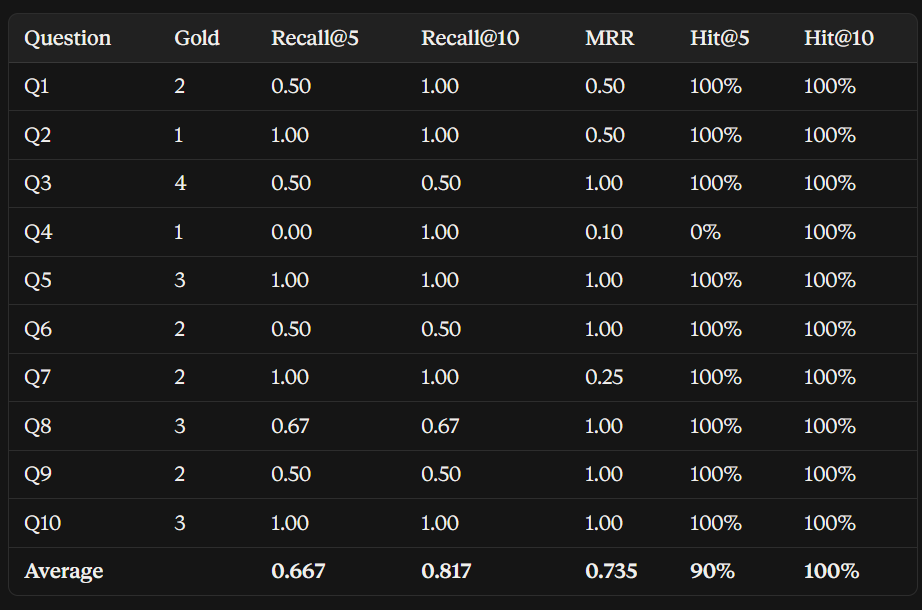

# RAGAS evaluation

(Done by manually redirecting routes to RAG generation)

Creating an update rag benchmark for RAGAS evaluation

In [ ]:
updated_rag_benchmark = [
  {
    "question": "What were the main reasons the researchers chose a 6B reward model instead of a 175B reward model, and what were the key training settings used for the final reward model?",
    "benchmark_answer": "The researchers chose a 6B reward model because the 175B reward model provided only limited additional benefit relative to its much greater computational cost. The 6B model offered a better practical trade-off between reward-model performance and training/inference cost. The final reward model was trained from a pretrained 6B GPT-3 model using human preference comparisons, where human labelers compared multiple model-generated responses and indicated which response was better. The training used a batch size of 64 and a learning rate of 9e-6. The comparison data was collected from prompts with multiple sampled completions, producing up to 2304 comparisons, and the reward model learned to assign higher scalar rewards to preferred responses.",
    "gold_chunks": [
      "semantic_chunk_998",
      "semantic_chunk_999"
    ],
    "generated_answer": "\\*\\*Answer\\*\\*\n\nThe researchers chose a \\*\\*6‑billion‑parameter reward model (RM)\\*\\* rather than a 175‑billion‑parameter one for two main reasons:\n\n1. \\*\\*Compute efficiency\\*\\* – a 6B RM requires far less computational resources, making the training pipeline much cheaper and faster.  \n2. \\*\\*Stability\\*\\* – they observed that training a 175B RM was often unstable and therefore less suitable to serve as the value function during reinforcement‑learning‑with‑human‑feedback (RLHF) (see Chunk 998)【semantic_chunk_998】.\n\nFor the \\*\\*final reward model\\*\\* they used the following training configuration:\n\n| Hyper‑parameter | Setting |\n|-----------------|---------|\n| \\*\\*Model size\\*\\* | 6 B parameters |\n| \\*\\*Batch size\\*\\* | 64 |\n| \\*\\*Learning rate\\*\\* | 4 × 10⁻⁶ (the learning‑rate that gave the best validation RM score) |\n| \\*\\*Learning‑rate schedule\\*\\* | Cosine decay to 10 % of the peak value by the end of training |\n| \\*\\*Number of training examples\\*\\* | 896 k examples (≈ 1 M) – the checkpoint with the highest RM score was selected after this amount of data |\n| \\*\\*Training objective\\*\\* | Reward‑model loss on human preference comparisons (cross‑entropy on pairwise logits) |\n\nThese settings were applied when fine‑tuning the FLAN and T0 baselines, and the same 6B RM was used to score completions and select the best checkpoint (see Chunk 1140)【semantic_chunk_1140】.\n\n---\n\n\\*\\*RESEARCH PAPER EVIDENCE\\*\\*\n\n- Motivation for using a 6B RM instead of a 175B RM: “In this paper we only use 6B RMs, as this saves a lot of compute, and we found that 175B RM training could be unstable and thus was less suitable to be used as the value function during RL”【semantic_chunk_998】.  \n- Final RM training configuration (batch size, learning‑rate choices, cosine schedule, 896k examples): “We applied a cosine learning rate schedule, and try initial learning rates of 4e-6 and 6e-6… batch size of 64… we picked the checkpoint with the highest RM score… trained with learning rate of 4e-6 and for 896k examples”【semantic_chunk_1140】.\n\n---\n\n\\*\\*Follow‑up question\\*\\*\n\nHow does the size of the reward model influence the stability and performance of the PPO fine‑tuning stage?",
    "retrieved_chunk_ids": [
      "semantic_chunk_1142",
      "semantic_chunk_998",
      "semantic_chunk_1140",
      "semantic_chunk_1139",
      "semantic_chunk_1161",
      "semantic_chunk_979",
      "semantic_chunk_1001",
      "semantic_chunk_999",
      "semantic_chunk_1165",
      "semantic_chunk_808"
    ],
    "retrieved_contexts": [
      "6.5\n6\n5.5\nReward mean\nLR = 4e-6\nModel\nFLAN\nT0\n250000 500000 750000 1000000 1250000\nElapsed examples\n6.5\n6\n5.5\nLR = 6e-6\nFigure 13: Tuning FLAN and T0 based on reward model scores\nbatch size of 64, a learning rate of 6e-6 and 1 million examples. Once again using the reward model\nscore, we picked the checkpoint from the former experiment after 896k examples of training.",
      "(2020)\nresearcher-researcher agreement was 73± 4%. 3.5 Models\nWe start with the GPT-3 pretrained language models from Brown et al. (2020). These models are\ntrained on a broad distribution of Internet data and are adaptable to a wide range of downstream tasks,\nbut have poorly characterized behavior. Starting from these models, we then train models with three\ndifferent techniques:\nSupervised ﬁne-tuning (SFT). We ﬁne-tune GPT-3 on our labeler demonstrations using supervised\nlearning. We trained for 16 epochs, using a cosine learning rate decay, and residual dropout of 0.2. We do our ﬁnal SFT model selection based on the RM score on the validation set. Similarly to Wu\net al. (2021), we ﬁnd that our SFT models overﬁt on validation loss after 1 epoch; however, we ﬁnd\nthat training for more epochs helps both the RM score and human preference ratings, despite this\noverﬁtting. Reward modeling (RM). Starting from the SFT model with the ﬁnal unembedding layer removed,\nwe trained a model to take in a prompt and response, and output a scalar reward. In this paper we\nonly use 6B RMs, as this saves a lot of compute, and we found that 175B RM training could be\nunstable and thus was less suitable to be used as the value function during RL (see Appendix C for\nmore details). In Stiennon et al.",
      "No discount is applied when estimating the generalized advantage (Schulman\net al., 2016). The PPO clip ratio is set to 0.2, and the sampling temperature is 1 for rollouts. As previously mentioned, for all PPO models we use a 6B RM and a 6B value function, and the latter\nis initialized from the former. By using the same 6B reward model and value function on policies of\nall model sizes, it’s easier to compare the effect of policy model size on policy performance. A ﬁxed\nlearning rate of 9e-6 for the value function is used for 1.3B and the 6B policies and 5e-6 for the 175B\npolicy. Our initial RLHF experiments showed regressions on public NLP datasets, such as SQuADv2 and\nDROP, and we mitigate the regressions by mixing in pretraining gradients during PPO training. We\nuse 8 times more pretraining examples than the number of the RL training episodes. The pretraining\ndata is randomly drawn from the dataset used to train the GPT-3 models. For each minibatch, we\ncompute the PPO gradients and pretraining gradients in consecutive steps and accumulate them\nboth into the gradient buffers. We multiply the pretraining gradients by a coefﬁcient,γ = 27.8 (see\nEquation 2), to control the relative strength of gradients from PPO and pretraining distributions. C.5 FLAN and T0 models\nWe obtain our FLAN and T0 baselines by ﬁne-tuning a 175B GPT-3 model on the FLAN and T0\ndatasets. For T0, note that we trained on the T0++ version of the dataset. Because T0 contains much\nmore data (96M datapoints) than FLAN (1.2M datapoints), we subsampled T0 to 1 million datapoints\nto make the amount of training data comparable for each model. Note that the original models train\non epochs where datapoints can be repeated, but in our epochs we go through every datapoint without\nrepeats (to better match the way we trained our SFT baselines). We applied a cosine learning rate\nschedule, and try initial learning rates of 4e-6 and 6e-6 for each dataset. The learning rate decays to\n10% of its peak at the end of training, and we use a batch size of 64 for both experiments. To choose the best FLAN checkpoint, we use our 6B reward model to score the completions on\nthe validation set of prompts. As shown in Figure 13, the reward saturates after the initial 400k\nexamples of training. This indicates that training for even longer will unlikely improve the human\neval performance. We picked the checkpoint with the highest RM score for our human evaluation,\nwhich is the one trained with learning rate of 4e-6 and for 896k examples. We perform two similar experiments to ﬁnd the best T0 checkpoint. In one experiment, we used a\nbatch size of 128, a learning rate of 4e-6 and 1.28 million examples.",
      "The resultant LR’s for the 1.3B, 6B, and\n175B models are 5e-6, 1.04e-5 and 2.45e-6, respectively. C.4 Details of RLHF training\nWe then initialize the RL policies from the above supervised ﬁne-tuned models with pretraining mix. These models are also used to compute the KL reward, in the same way as Stiennon et al. (2020), with\nβ = 0.02 (see Equation 2). We train all the RL models for 256k episodes. These episodes include\nabout 31k unique prompts, after ﬁltering out prompts with PII and deduplication based on common\npreﬁxes. The batch size for each iteration is 512, with a minibatch size of 64. In other words, each\nbatch is randomly split into 8 minibatches and is trained on for only a single inner epoch (Schulman\net al., 2017). A constant learning rate is applied with a warmup over the ﬁrst 10 iterations, starting\nwith one tenth of the peak learning rate. Exponential moving averages of the weights are applied, with\na decay rate of 0.992.",
      "By setting\npretraining loss coefﬁcient to greater or equal 20, the regression on these tasks can be recovered,\non the 1.3B model. We also noticed that the sensitivity to pretraining loss coefﬁcient varies across\ntasks. Although increasing the pretraining loss coefﬁcient causes the validation reward to drop, a\nsingle value of 27.8 seems to work well across model sizes, from 1.3B to 175B parameter count. The\nhuman likert score appeared to be insensitive to the exact values of pretraining loss coefﬁcient in our\nablation studies. We further investigate whether increasing the coefﬁcient of KL reward (β in Equation 2) is sufﬁcient\nto ﬁx the regressions on public NLP datasets, using the 1.3B model. We set the pretraining loss\ncoefﬁcient to 0 and sweep a range of KL reward coefﬁcient’s uniformly in log linear space. The\nresults are shown in Figure 34. The pretrained GPT model is used as the KL reward model, in\nthese experiments. We ﬁnd that even by increasing the KL reward coefﬁcient to 2.0, which is 100\ntimes of the default value, the regressions still cannot be ﬁxed. As expected, too large KL reward\ncoefﬁcient causes a signiﬁcant drop in the validation reward. This result demonstrates that pretraining\ndata distribution is critical for ﬁxing the regressions on the public NLP datasets and maintaining the\ncapabilities of the pretrained model. 53",
      "Figure 2: A diagram illustrating the three steps of our method: (1) supervised ﬁne-tuning (SFT), (2)\nreward model (RM) training, and (3) reinforcement learning via proximal policy optimization (PPO)\non this reward model. Blue arrows indicate that this data is used to train one of our models.",
      "Once again following Stiennon et al. (2020), we ﬁne-tuned the\nSFT model on our environment using PPO (Schulman et al., 2017). The environment is a bandit\nenvironment which presents a random customer prompt and expects a response to the prompt. Given\nthe prompt and response, it produces a reward determined by the reward model and ends the episode. In addition, we add a per-token KL penalty from the SFT model at each token to mitigate over-\noptimization of the reward model. The value function is initialized from the RM. We call these\nmodels “PPO.”\nWe also experiment with mixing the pretraining gradients into the PPO gradients, in order to ﬁx the\nperformance regressions on public NLP datasets. We call these models “PPO-ptx.” We maximize the\nfollowing combined objective function in RL training:\nobjective (φ) =E(x,y)∼DπRL\nφ\n[\nrθ(x,y )−β log\n(\nπRL\nφ (y|x)/πSFT(y|x)\n)]\n+\nγEx∼Dpretrain\n[\nlog(πRL\nφ (x))\n] (2)\nwhere πRL\nφ is the learned RL policy, πSFT is the supervised trained model, and Dpretrain is the\npretraining distribution. The KL reward coefﬁcient,β, and the pretraining loss coefﬁcient,γ, control\nthe strength of the KL penalty and pretraining gradients respectively. For \"PPO\" models,γ is set to 0. Unless otherwise speciﬁed, in this paper InstructGPT refers to the PPO-ptx models. Baselines. We compare the performance of our PPO models to our SFT models and GPT-3. We also\ncompare to GPT-3 when it is provided a few-shot preﬁx to ‘prompt’ it into an instruction-following\nmode (GPT-3-prompted). This preﬁx is prepended to the user-speciﬁed instruction.6\nWe additionally compare InstructGPT to ﬁne-tuning 175B GPT-3 on the FLAN (Wei et al., 2021) and\nT0 (Sanh et al., 2021) datasets, which both consist of a variety of NLP tasks, combined with natural\nlanguage instructions for each task (the datasets differ in the NLP datasets included, and the style of\ninstructions used). We ﬁne-tune them on approximately 1 million examples respectively and choose\nthe checkpoint which obtains the highest reward model score on the validation set.",
      "(2020), the RM is trained on a dataset of comparisons between two model outputs\non the same input. They use a cross-entropy loss, with the comparisons as labels—the difference in\nrewards represents the log odds that one response will be preferred to the other by a human labeler. In order to speed up comparison collection, we present labelers with anywhere betweenK = 4 and\nK = 9 responses to rank. This produces\n(K\n2\n)\ncomparisons for each prompt shown to a labeler. Since\ncomparisons are very correlated within each labeling task, we found that if we simply shufﬂe the\ncomparisons into one dataset, a single pass over the dataset caused the reward model to overﬁt. 5\nInstead, we train on all\n(K\n2\n)\ncomparisons from each prompt as a single batch element. This is much\nmore computationally efﬁcient because it only requires a single forward pass of the RM for each\ncompletion (rather than\n(K\n2\n)\nforward passes forK completions) and, because it no longer overﬁts, it\nachieves much improved validation accuracy and log loss. Speciﬁcally, the loss function for the reward model is:\nloss (θ) =− 1(K\n2\n)E(x,yw,yl)∼D [log (σ (rθ (x,yw)−rθ (x,yl)))] (1)\nwhererθ(x,y ) is the scalar output of the reward model for promptx and completiony with parameters\nθ, yw is the preferred completion out of the pair of yw and yl, and D is the dataset of human\ncomparisons. 5That is, if each of the possible\n(K\n2\n)\ncomparisons is treated as a separate data point, then each completion\nwill potentially be used for K− 1 separate gradient updates. The model tends to overﬁt after a single epoch, so\nrepeating data within an epoch also causes it to overﬁt.",
      "Instead of training for 256k episodes, we train for 512k episodes. As can be seen, on\nDROP and SquadV2, the model starts out with better performance than the GPT-3 model. As training\ngoes on, the performance on both tasks drops slightly below the GPT-3 baseline. E.7 Optimal KL reward coefﬁcient\nEven with the pretraining data mix for PPO training, it’s still important to tune the KL reward\ncoefﬁcient properly. In Figure 36, we show the human likert score as a function of the KL reward\ncoefﬁcient. Both 0 and 2 for KL reward coefﬁcient result in poor performance.",
      "guage models trained on a large amount of text – where ﬁne-tuning on task-speciﬁc data after pre-\ntraining on general domain data provides a signiﬁcant performance gain compared to training on\ntask-speciﬁc data directly. Training larger Transformers generally results in better performance and\nremains an active research direction. GPT-3 (Brown et al., 2020) is the largest single Transformer\nlanguage model trained to-date with 175B parameters. Prompt Engineering and Fine-Tuning. While GPT-3 175B can adapt its behavior with just a\nfew additional training examples, the result depends heavily on the input prompt (Brown et al.,\n2020). This necessitates an empirical art of composing and formatting the prompt to maximize a\nmodel’s performance on a desired task, which is known as prompt engineering or prompt hacking. Fine-tuning retrains a model pre-trained on general domains to a speciﬁc task Devlin et al."
    ]
  },
  {
    "question": "How does the RAG architecture differ from prior work in single-task retrieval and general-purpose NLP architectures, and what are the two key advantages of using raw text as the external memory instead of distributed representations?",
    "benchmark_answer": "RAG combines a pretrained sequence-to-sequence generator with a neural retriever that accesses an external non-parametric memory. Unlike earlier retrieval systems that were often designed for a specific task such as open-domain question answering, RAG provides a general retrieval-augmented architecture that can be applied to different NLP generation tasks. The external memory consists of retrievable text passages rather than knowledge stored entirely inside model parameters. Using raw text provides two important advantages: it is human-readable and therefore easier to inspect, and it is human-writable, meaning the external memory can be updated or modified without retraining the entire generator. This separates the model's parametric knowledge from an independently editable external knowledge source.",
    "gold_chunks": [
      "semantic_chunk_914"
    ],
    "generated_answer": "\\*\\*How RAG differs from earlier approaches\\*\\*\n\n\\* \\*\\*Beyond single‑task retrieval\\*\\* – Earlier retrieval‑based systems train a retriever to help a \\*specific\\* downstream task (e.g., question answering) and are not meant to be reused for other tasks. RAG, by contrast, learns a retrieval module that can be \\*\\*fine‑tuned once and then applied to many knowledge‑intensive NLP tasks\\*\\* with a single architecture 【semantic_chunk_914】.  \n\n\\* \\*\\*Beyond pure parametric models\\*\\* – General‑purpose NLP architectures such as BERT, GPT‑2, BART, or T5 rely only on \\*\\*parametric (internal) memory\\*\\* learned during pre‑training. RAG augments a pre‑trained seq2seq transformer (the parametric memory) with a \\*\\*non‑parametric external memory\\*\\* (a dense vector index of raw Wikipedia text) and trains the whole system end‑to‑end 【semantic_chunk_887】【semantic_chunk_883】. This hybrid design lets the model retrieve up‑to‑date factual information at inference time, something pure parametric models cannot do.\n\n\\*\\*Why raw text is used as the external memory\\*\\*\n\n1. \\*\\*Human‑readable (interpretability)\\*\\* – Storing raw passages rather than opaque embeddings means the retrieved evidence can be inspected directly, giving users insight into why the model generated a particular output 【semantic_chunk_914】.  \n\n2. \\*\\*Human‑writable (updatability)\\*\\* – Because the memory consists of editable text, practitioners can \\*\\*modify or add documents in the index\\*\\* to change the model’s knowledge without any retraining, simply by editing the external corpus 【semantic_chunk_914】.\n\n---\n\n\\*\\*RESEARCH PAPER EVIDENCE\\*\\*\n\n- \\*Differences from prior single‑task retrieval and general‑purpose architectures\\*: “Some work optimizes the retrieval module to aid in a specific, downstream task… while we show that a single retrieval‑based architecture can be fine‑tuned for strong performance on a variety of tasks.” 【semantic_chunk_914】  \n- \\*Hybrid parametric‑non‑parametric design\\*: “We endow pre‑trained, parametric‑memory generation models with a non‑parametric memory… via a general‑purpose fine‑tuning approach which we refer to as retrieval‑augmented generation (RAG).” 【semantic_chunk_887】  \n- \\*Advantages of raw‑text memory\\*: “A key feature of our memory is that it is comprised of raw text rather than distributed representations, which makes the memory both (i) human‑readable… and (ii) human‑writable, enabling us to dynamically update the model’s memory by editing the document index.” 【semantic_chunk_914】\n\n---\n\n\\*\\*Follow‑up question\\*\\*\n\nHow do the two RAG variants (RAG‑Sequence vs. RAG‑Token) differ in how they incorporate retrieved passages during generation, and what impact does this have on task performance?",
    "retrieved_chunk_ids": [
      "semantic_chunk_917",
      "semantic_chunk_914",
      "semantic_chunk_887",
      "semantic_chunk_883",
      "semantic_chunk_882",
      "semantic_chunk_965",
      "semantic_chunk_901",
      "semantic_chunk_910",
      "semantic_chunk_888",
      "semantic_chunk_971"
    ],
    "retrieved_contexts": [
      "We\nfound that people prefer RAG’s generation over purely parametric BART, ﬁnding RAG more factual\nand speciﬁc. We conducted an thorough investigation of the learned retrieval component, validating\nits effectiveness, and we illustrated how the retrieval index can be hot-swapped to update the model\nwithout requiring any retraining. In future work, it may be fruitful to investigate if the two components\ncan be jointly pre-trained from scratch, either with a denoising objective similar to BART or some\nanother objective. Our work opens up new research directions on how parametric and non-parametric\nmemories interact and how to most effectively combine them, showing promise in being applied to a\nwide variety of NLP tasks. 9",
      "General-Purpose Architectures for NLP Prior work on general-purpose architectures for NLP\ntasks has shown great success without the use of retrieval. A single, pre-trained language model\nhas been shown to achieve strong performance on various classiﬁcation tasks in the GLUE bench-\nmarks [60, 61] after ﬁne-tuning [49, 8]. GPT-2 [50] later showed that a single, left-to-right, pre-trained\nlanguage model could achieve strong performance across both discriminative and generative tasks. For further improvement, BART [32] and T5 [51, 52] propose a single, pre-trained encoder-decoder\nmodel that leverages bi-directional attention to achieve stronger performance on discriminative\nand generative tasks. Our work aims to expand the space of possible tasks with a single, uniﬁed\narchitecture, by learning a retrieval module to augment pre-trained, generative language models. Learned Retrieval There is signiﬁcant work on learning to retrieve documents in information\nretrieval, more recently with pre-trained, neural language models [ 44, 26] similar to ours. Some\nwork optimizes the retrieval module to aid in a speciﬁc, downstream task such as question answering,\nusing search [46], reinforcement learning [6, 63, 62], or a latent variable approach [31, 20] as in our\nwork. These successes leverage different retrieval-based architectures and optimization techniques to\nachieve strong performance on a single task, while we show that a single retrieval-based architecture\ncan be ﬁne-tuned for strong performance on a variety of tasks. Memory-based Architectures Our document index can be seen as a large external memory for\nneural networks to attend to, analogous to memory networks [64, 55]. Concurrent work [14] learns\nto retrieve a trained embedding for each entity in the input, rather than to retrieve raw text as in our\nwork. Other work improves the ability of dialog models to generate factual text by attending over\nfact embeddings [15, 13]. A key feature of our memory is that it is comprised of raw text rather\ndistributed representations, which makes the memory both (i) human-readable, lending a form of\ninterpretability to our model, and (ii) human-writable, enabling us to dynamically update the model’s\nmemory by editing the document index. This approach has also been used in knowledge-intensive\ndialog, where generators have been conditioned on retrieved text directly, albeit obtained via TF-IDF\nrather than end-to-end learnt retrieval [9]. Retrieve-and-Edit approaches Our method shares some similarities with retrieve-and-edit style\napproaches, where a similar training input-output pair is retrieved for a given input, and then edited\nto provide a ﬁnal output. These approaches have proved successful in a number of domains including\nMachine Translation [ 18, 22] and Semantic Parsing [21]. Our approach does have several differences,\nincluding less of emphasis on lightly editing a retrieved item, but on aggregating content from several\npieces of retrieved content, as well as learning latent retrieval, and retrieving evidence documents\nrather than related training pairs.",
      "but have only explored open-domain extractive question answering. Here, we bring hybrid parametric\nand non-parametric memory to the “workhorse of NLP,” i.e. sequence-to-sequence (seq2seq) models. We endow pre-trained, parametric-memory generation models with a non-parametric memory through\na general-purpose ﬁne-tuning approach which we refer to as retrieval-augmented generation (RAG). We build RAG models where the parametric memory is a pre-trained seq2seq transformer, and the\nnon-parametric memory is a dense vector index of Wikipedia, accessed with a pre-trained neural\nretriever. We combine these components in a probabilistic model trained end-to-end (Fig.",
      "Additionally, providing provenance for their\ndecisions and updating their world knowledge remain open research problems. Pre-\ntrained models with a differentiable access mechanism to explicit non-parametric\nmemory have so far been only investigated for extractive downstream tasks. We\nexplore a general-purpose ﬁne-tuning recipe for retrieval-augmented generation\n(RAG) — models which combine pre-trained parametric and non-parametric mem-\nory for language generation. We introduce RAG models where the parametric\nmemory is a pre-trained seq2seq model and the non-parametric memory is a dense\nvector index of Wikipedia, accessed with a pre-trained neural retriever. We com-\npare two RAG formulations, one which conditions on the same retrieved passages\nacross the whole generated sequence, and another which can use different passages\nper token. We ﬁne-tune and evaluate our models on a wide range of knowledge-\nintensive NLP tasks and set the state of the art on three open domain QA tasks,\noutperforming parametric seq2seq models and task-speciﬁc retrieve-and-extract\narchitectures. For language generation tasks, we ﬁnd that RAG models generate\nmore speciﬁc, diverse and factual language than a state-of-the-art parametric-only\nseq2seq baseline. 1 Introduction\nPre-trained neural language models have been shown to learn a substantial amount of in-depth knowl-\nedge from data [47]. They can do so without any access to an external memory, as a parameterized\nimplicit knowledge base [51, 52].",
      "Retrieval-Augmented Generation for\nKnowledge-Intensive NLP Tasks\nPatrick Lewis†‡, Ethan Perez⋆,\nAleksandra Piktus†, Fabio Petroni†, Vladimir Karpukhin†, Naman Goyal†, Heinrich Küttler†,\nMike Lewis†, Wen-tau Yih†, Tim Rocktäschel†‡, Sebastian Riedel†‡, Douwe Kiela†\n†Facebook AI Research;‡University College London;⋆New York University;\nplewis@fb.com\nAbstract\nLarge pre-trained language models have been shown to store factual knowledge\nin their parameters, and achieve state-of-the-art results when ﬁne-tuned on down-\nstream NLP tasks. However, their ability to access and precisely manipulate knowl-\nedge is still limited, and hence on knowledge-intensive tasks, their performance\nlags behind task-speciﬁc architectures.",
      "Appendices for Retrieval-Augmented Generation for\nKnowledge-Intensive NLP Tasks\nA Implementation Details\nFor Open-domain QA we report test numbers using 15 retrieved documents for RAG-Token models. For RAG-Sequence models, we report test results using 50 retrieved documents, and we use the\nThorough Decoding approach since answers are generally short. We use greedy decoding for QA as\nwe did not ﬁnd beam search improved results. For Open-MSMarco and Jeopardy question generation,\nwe report test numbers using ten retrieved documents for both RAG-Token and RAG-Sequence,\nand we also train a BART-large model as a baseline. We use a beam size of four, and use the Fast\nDecoding approach for RAG-Sequence models, as Thorough Decoding did not improve performance. B Human Evaluation\nFigure 4: Annotation interface for human evaluation of factuality.",
      "We explore\ntwo variants: the standard 3-way classiﬁcation task (supports/refutes/not enough info) and the 2-way\n(supports/refutes) task studied in Thorne and Vlachos [57]. In both cases we report label accuracy. 4 Results\n4.1 Open-domain Question Answering\nTable 1 shows results for RAG along with state-of-the-art models. On all four open-domain QA\ntasks, RAG sets a new state of the art (only on the T5-comparable split for TQA). RAG combines\nthe generation ﬂexibility of the “closed-book” (parametric only) approaches and the performance of\n\"open-book\" retrieval-based approaches. Unlike REALM and T5+SSM, RAG enjoys strong results\nwithout expensive, specialized “salient span masking” pre-training [20]. It is worth noting that RAG’s\nretriever is initialized using DPR’s retriever, which uses retrieval supervision on Natural Questions\nand TriviaQA. RAG compares favourably to the DPR QA system, which uses a BERT-based “cross-\nencoder” to re-rank documents, along with an extractive reader. RAG demonstrates that neither a\nre-ranker nor extractive reader is necessary for state-of-the-art performance. There are several advantages to generating answers even when it is possible to extract them. Docu-\nments with clues about the answer but do not contain the answer verbatim can still contribute towards\na correct answer being generated, which is not possible with standard extractive approaches, leading\n5",
      "We also analyze whether documents retrieved by RAG correspond to documents annotated as gold\nevidence in FEVER. We calculate the overlap in article titles between the topk documents retrieved\nby RAG and gold evidence annotations. We ﬁnd that the top retrieved document is from a gold article\nin 71% of cases, and a gold article is present in the top 10 retrieved articles in 90% of cases. 4.5 Additional Results\nGeneration Diversity Section 4.3 shows that RAG models are more factual and speciﬁc than\nBART for Jeopardy question generation. Following recent work on diversity-promoting decoding\n[33, 59, 39], we also investigate generation diversity by calculating the ratio of distinct ngrams to\ntotal ngrams generated by different models. Table 5 shows that RAG-Sequence’s generations are\nmore diverse than RAG-Token’s, and both are signiﬁcantly more diverse than BART without needing\nany diversity-promoting decoding. Retrieval Ablations A key feature of RAG is learning to retrieve relevant information for the task. To assess the effectiveness of the retrieval mechanism, we run ablations where we freeze the retriever\nduring training. As shown in Table 6, learned retrieval improves results for all tasks. We compare RAG’s dense retriever to a word overlap-based BM25 retriever [53]. Here, we replace\nRAG’s retriever with a ﬁxed BM25 system, and use BM25 retrieval scores as logits when calculating\np(z|x). Table 6 shows the results. For FEVER, BM25 performs best, perhaps since FEVER claims are\nheavily entity-centric and thus well-suited for word overlap-based retrieval. Differentiable retrieval\nimproves results on all other tasks, especially for Open-Domain QA, where it is crucial. Index hot-swapping An advantage of non-parametric memory models like RAG is that knowledge\ncan be easily updated at test time. Parametric-only models like T5 or BART need further training to\nupdate their behavior as the world changes. To demonstrate, we build an index using the DrQA [5]\nWikipedia dump from December 2016 and compare outputs from RAG using this index to the newer\nindex from our main results (December 2018). We prepare a list of 82 world leaders who had changed\n7",
      "1). The\nretriever (Dense Passage Retriever [26], henceforth DPR) provides latent documents conditioned on\nthe input, and the seq2seq model (BART [32]) then conditions on these latent documents together with\nthe input to generate the output. We marginalize the latent documents with a top-K approximation,\neither on a per-output basis (assuming the same document is responsible for all tokens) or a per-token\nbasis (where different documents are responsible for different tokens). Like T5 [51] or BART, RAG\ncan be ﬁne-tuned on any seq2seq task, whereby both the generator and retriever are jointly learned. There has been extensive previous work proposing architectures to enrich systems with non-parametric\nmemory which are trained from scratch for speciﬁc tasks, e.g. memory networks [ 64, 55], stack-\naugmented networks [25] and memory layers [ 30]. In contrast, we explore a setting where both\nparametric and non-parametric memory components are pre-trained and pre-loaded with extensive\nknowledge. Crucially, by using pre-trained access mechanisms, the ability to access knowledge is\npresent without additional training. Our results highlight the beneﬁts of combining parametric and non-parametric memory with genera-\ntion for knowledge-intensive tasks—tasks that humans could not reasonably be expected to perform\nwithout access to an external knowledge source. Our RAG models achieve state-of-the-art results\non open Natural Questions [29], WebQuestions [3] and CuratedTrec [2] and strongly outperform\nrecent approaches that use specialised pre-training objectives on TriviaQA [24]. Despite these being\nextractive tasks, we ﬁnd that unconstrained generation outperforms previous extractive approaches. For knowledge-intensive generation, we experiment with MS-MARCO [1] and Jeopardy question\ngeneration, and we ﬁnd that our models generate responses that are more factual, speciﬁc, and\ndiverse than a BART baseline. For FEVER [56] fact veriﬁcation, we achieve results within 4.3% of\nstate-of-the-art pipeline models which use strong retrieval supervision. Finally, we demonstrate that\nthe non-parametric memory can be replaced to update the models’ knowledge as the world changes.1\n2 Methods\nWe explore RAG models, which use the input sequencex to retrieve text documentsz and use them\nas additional context when generating the target sequence y. As shown in Figure 1, our models\nleverage two components: (i) a retriever pη(z|x) with parametersη that returns (top-K truncated)\ndistributions over text passages given a queryx and (ii) a generatorpθ(yi|x,z,y 1:i−1) parametrized\n1Code to run experiments with RAG has been open-sourced as part of the HuggingFace Transform-\ners Library [66] and can be found at https://github.com/huggingface/transformers/blob/master/\nexamples/rag/. An interactive demo of RAG models can be found at https://huggingface.co/rag/\n2",
      "For Open MS-MARCO, where useful retrieved documents\ncannot always be retrieved, we observe that the model learns to always retrieve a particular set of\ndocuments for questions that are less likely to beneﬁt from retrieval, suggesting that null document\nmechanisms may not be necessary for RAG. G Parameters\nOur RAG models contain the trainable parameters for the BERT-base query and document encoder of\nDPR, with 110M parameters each (although we do not train the document encoder ourselves) and\n406M trainable parameters from BART-large, 406M parameters, making a total of 626M trainable\n18"
    ]
  },
  {
    "question": "Why is fine-tuning GPT-3 175B challenging in practice, and how does LoRA address the limitations of both traditional fine-tuning and adapter layers while maintaining inference efficiency?",
    "benchmark_answer": "Fine-tuning GPT-3 175B is extremely expensive because updating all of its parameters requires enormous computational resources, GPU memory, and storage. LoRA addresses this by freezing the pretrained model weights and learning only low-rank updates to selected weight matrices. Instead of directly learning a full update to a weight matrix W, LoRA represents the update using two much smaller matrices, typically written as W' = W + BA. This dramatically reduces the number of trainable parameters and the memory required during fine-tuning. Adapter methods also reduce the number of trainable parameters, but they introduce additional layers into the model and can therefore add inference latency. LoRA avoids this because its learned low-rank matrices can be merged into the original weights after training, allowing the adapted model to run without additional inference layers or latency.",
    "gold_chunks": [
      "semantic_chunk_810",
      "semantic_chunk_780",
      "semantic_chunk_792",
      "semantic_chunk_852"
    ],
    "generated_answer": "\\*\\*Practical challenges of fine‑tuning a 175‑billion‑parameter GPT‑3\\*\\*\n\n\\* \\*\\*Memory and hardware barrier\\*\\* – The full GPT‑3 checkpoint is ≈350 GB. Fine‑tuning requires loading and updating the entire model, which has the same memory footprint as pre‑training and therefore demands very large GPU clusters or specialized hardware 【semantic_chunk_777】.  \n\\* \\*\\*Training throughput\\*\\* – Full fine‑tuning of GPT‑3 175B runs at only about 32.5 tokens / s per V100 GPU, making the process slow and costly 【semantic_chunk_794】.  \n\\* \\*\\*Deployment and storage cost\\*\\* – Each fine‑tuned model produces a new 350 GB checkpoint. Storing many task‑specific models quickly becomes infeasible (e.g., 100 models would need ≈35 TB) 【semantic_chunk_794】.  \n\n\\*\\*How Low‑Rank Adaptation (LoRA) overcomes these limitations\\*\\*\n\n\\* \\*\\*Parameter‑efficient updates\\*\\* – LoRA freezes the original weights and learns only two low‑rank matrices \\*\\*A\\*\\* and \\*\\*B\\*\\* (the “bottleneck” structure). This reduces trainable parameters to a tiny fraction of the full model (e.g., \\~35 MB per task) while still achieving comparable or better performance 【semantic_chunk_777】【semantic_chunk_794】.  \n\\* \\*\\*No inference latency\\*\\* – Unlike adapter layers that insert extra modules and increase runtime, LoRA’s learned low‑rank updates can be \\*\\*merged\\*\\* with the original weight matrices after training. Consequently, inference uses the original architecture with no added latency 【semantic_chunk_810】.  \n\\* \\*\\*Higher training throughput\\*\\* – Because only the small LoRA matrices are updated, the training speed improves to about 43.1 tokens / s per V100 GPU, a noticeable gain over full fine‑tuning 【semantic_chunk_794】.  \n\\* \\*\\*Scalability and performance\\*\\* – Experiments scaling LoRA to GPT‑3 175B show it matches or exceeds full fine‑tuning on several benchmarks, demonstrating that the low‑rank constraint does not sacrifice accuracy while keeping the model size unchanged 【semantic_chunk_807】.  \n\n\\*\\*RESEARCH PAPER EVIDENCE\\*\\*\n\n- \\*\\*Fine‑tuning challenges:\\*\\* “The major downside of fine‑tuning is that the new model contains as many parameters as in the original model… for GPT‑3 175B… this changes from a mere ‘inconvenience’… to a critical deployment challenge” 【semantic_chunk_777】.  \n- \\*\\*Memory & storage:\\*\\* “We still need the 350 GB model during deployment… storing 100 adapted models only requires 350 GB + 35 MB × 100 ≈ 354 GB as opposed to 100 × 350 GB ≈ 35 TB” 【semantic_chunk_794】.  \n- \\*\\*Throughput comparison:\\*\\* “For GPT‑3 175B, the training throughput for full fine‑tuning is 32.5 tokens/s per V100 GPU; … 43.1 tokens/s per V100 GPU for LoRA” 【semantic_chunk_794】.  \n- \\*\\*Adapter vs. LoRA latency:\\*\\* “Our learned weights can be merged with the main weights during inference, thus not introducing any latency, which is not the case for the adapter layers” 【semantic_chunk_810】.  \n- \\*\\*Performance at scale:\\*\\* “LoRA matches or exceeds the fine‑tuning baseline on all three datasets… LoRA exhibits better scalability and task performance” 【semantic_chunk_807】.  \n\n\\*\\*Follow‑up question\\*\\*\n\nHow does LoRA perform when only a small amount of labeled data is available for a downstream task compared to other parameter‑efficient adaptation methods?",
    "retrieved_chunk_ids": [
      "semantic_chunk_810",
      "semantic_chunk_794",
      "semantic_chunk_789",
      "semantic_chunk_807",
      "semantic_chunk_780",
      "semantic_chunk_877",
      "semantic_chunk_776",
      "semantic_chunk_777",
      "semantic_chunk_778",
      "semantic_chunk_869"
    ],
    "retrieved_contexts": [
      "(2019b);\nCollobert & Weston (2008), yet practitioners often retrain all of them to maximize the downstream\nperformance. However, the enormity of GPT-3 175B makes it challenging to perform ﬁne-tuning in\nthe usual way due to the large checkpoint it produces and the high hardware barrier to entry since it\nhas the same memory footprint as pre-training. Parameter-Efﬁcient Adaptation. Many have proposed inserting adapter layers between existing\nlayers in a neural network (Houlsby et al., 2019; Rebufﬁ et al., 2017; Lin et al., 2020). Our method\nuses a similar bottleneck structure to impose a low-rank constraint on the weight updates. The\nkey functional difference is that our learned weights can be merged with the main weights during\ninference, thus not introducing any latency, which is not the case for the adapter layers (Section 3). A comtenporary extension of adapter is COMPACTER (Mahabadi et al., 2021), which essentially\nparametrizes the adapter layers using Kronecker products with some predetermined weight sharing\nscheme. Similarly, combining LoRA with other tensor product-based methods could potentially\nimprove its parameter efﬁciency, which we leave to future work. More recently, many proposed\noptimizing the input word embeddings in lieu of ﬁne-tuning, akin to a continuous and differentiable\ngeneralization of prompt engineering (Li & Liang, 2021; Lester et al., 2021; Hambardzumyan et al.,\n2020; Liu et al., 2021).",
      "Fine-Tuning (FT)is a common approach for adaptation. During ﬁne-tuning, the model is initialized\nto the pre-trained weights and biases, and all model parameters undergo gradient updates.A simple\nvariant is to update only some layers while freezing others. We include one such baseline reported\nin prior work (Li & Liang, 2021) on GPT-2, which adapts just the last two layers (FTTop2). 4We still need the 350GB model during deployment; however, storing 100 adapted models only requires\n350GB + 35MB * 100≈ 354GB as opposed to 100 * 350GB≈ 35TB. 5For GPT-3 175B, the training throughput for full ﬁne-tuning is 32.5 tokens/s per V100 GPU; with the same\nnumber of weight shards for model parallelism, the throughput is 43.1 tokens/s per V100 GPU for LoRA. 5",
      "A more general form of ﬁne-tuning allows the training of\na subset of the pre-trained parameters. LoRA takes a step further and does not require the accumu-\nlated gradient update to weight matrices to have full-rank during adaptation. This means that when\napplying LoRA to all weight matrices and training all biases 2, we roughly recover the expressive-\nness of full ﬁne-tuning by setting the LoRA rankr to the rank of the pre-trained weight matrices. In\nother words, as we increase the number of trainable parameters 3, training LoRA roughly converges\nto training the original model, while adapter-based methods converges to an MLP and preﬁx-based\nmethods to a model that cannot take long input sequences. No Additional Inference Latency.",
      "The results\non WikiSQL have a ﬂuctuation around ±0.5%, MNLI-m around ±0.1%, and SAMSum around\n±0.2/±0.2/±0.1 for the three metrics. 5.5 S CALING UP TO GPT-3 175B\nAs a ﬁnal stress test for LoRA, we scale up to GPT-3 with 175 billion parameters. Due to the high\ntraining cost, we only report the typical standard deviation for a given task over random seeds, as\nopposed to providing one for every entry. See Section D.4 for details on the hyperparameters used. As shown in Table 4, LoRA matches or exceeds the ﬁne-tuning baseline on all three datasets. Note\nthat not all methods beneﬁt monotonically from having more trainable parameters, as shown in Fig-\nure 2. We observe a signiﬁcant performance drop when we use more than 256 special tokens for\npreﬁx-embedding tuning or more than 32 special tokens for preﬁx-layer tuning. This corroborates\nsimilar observations in Li & Liang (2021). While a thorough investigation into this phenomenon\nis out-of-scope for this work, we suspect that having more special tokens causes the input distri-\nbution to shift further away from the pre-training data distribution. Separately, we investigate the\nperformance of different adaptation approaches in the low-data regime in Section F.3. 6 7 8 9 10 11\nlog10 # Trainable Parameters\n0.55\n0.60\n0.65\n0.70\n0.75Validation Accuracy\nWikiSQL\nMethod\nFine-Tune\nPrefixEmbed\nPrefixLayer\nAdapter(H)\nLoRA\n6 7 8 9 10 11\nlog10 # Trainable Parameters\n0.84\n0.86\n0.88\n0.90\n0.92\nMultiNLI-matched\nFigure 2: GPT-3 175B validation accuracy vs. number of trainable parameters of several adaptation\nmethods on WikiSQL and MNLI-matched. LoRA exhibits better scalability and task performance. See Section F.2 for more details on the plotted data points. 6 R ELATED WORKS\nTransformer Language Models. Transformer (Vaswani et al., 2017) is a sequence-to-sequence\narchitecture that makes heavy use of self-attention. Radford et al. (a) applied it to autoregressive lan-\nguage modeling by using a stack of Transformer decoders. Since then, Transformer-based language\nmodels have dominated NLP, achieving the state-of-the-art in many tasks. A new paradigm emerged\nwith BERT (Devlin et al., 2019b) and GPT-2 (Radford et al., b) – both are large Transformer lan-\n8",
      "(2018a); Aghajanyan et al. (2020) which show that the learned\nover-parametrized models in fact reside on a low intrinsic dimension. We hypothesize that the\nchange in weights during model adaptation also has a low “intrinsic rank”, leading to our proposed\nLow-Rank Adaptation (LoRA) approach. LoRA allows us to train some dense layers in a neural\nnetwork indirectly by optimizing rank decomposition matrices of the dense layers’ change during\nadaptation instead, while keeping the pre-trained weights frozen, as shown in Figure 1. Using GPT-3\n175B as an example, we show that a very low rank (i.e.,r in Figure 1 can be one or two) sufﬁces even\nwhen the full rank (i.e., d) is as high as 12,288, making LoRA both storage- and compute-efﬁcient. LoRA possesses several key advantages. • A pre-trained model can be shared and used to build many small LoRA modules for dif-\nferent tasks. We can freeze the shared model and efﬁciently switch tasks by replacing the\nmatricesA andB in Figure 1, reducing the storage requirement and task-switching over-\nhead signiﬁcantly. • LoRA makes training more efﬁcient and lowers the hardware barrier to entry by up to 3\ntimes when using adaptive optimizers since we do not need to calculate the gradients or\nmaintain the optimizer states for most parameters. Instead, we only optimize the injected,\nmuch smaller low-rank matrices. • Our simple linear design allows us to merge the trainable matrices with the frozen weights\nwhen deployed, introducing no inference latency compared to a fully ﬁne-tuned model, by\nconstruction. • LoRA is orthogonal to many prior methods and can be combined with many of them, such\nas preﬁx-tuning.",
      "Otherwise,φ(A,B,i,j )∈ (0, 1). H A DDITIONAL EXPERIMENTS ON LOW-RANK MATRICES\nWe present additional results from our investigation into the low-rank update matrices. H.1 C ORRELATION BETWEEN LORA M ODULES\nSee Figure 6 and Figure 7 for how the results presented in Figure 3 and Figure 4 generalize to other\nlayers. H.2 E FFECT OF r ON GPT-2\nWe repeat our experiment on the effect ofr (Section 7.2) in GPT-2. Using the E2E NLG Challenge\ndataset as an example, we report the validation loss and test metrics achieved by different choices\nofr after training for 26,000 steps. We present our result in Table 18. The optimal rank for GPT-2\nMedium is between 4 and 16 depending on the metric used, which is similar to that for GPT-3 175B. Note that the relationship between model size and the optimal rank for adaptation is still an open\nquestion. H.3 C ORRELATION BETWEEN W AND ∆W\nSee Figure 8 for the normalized subspace similarity betweenW and ∆W with varyingr. Note again that ∆W does not contain the top singular directions ofW , since the similarity between\nthe top 4 directions in ∆W and the top-10% of those inW barely exceeds 0.2. This gives evidence\nthat ∆W contains those “task-speciﬁc” directions that are otherwise not emphasized inW . An interesting next question to answer, is how “strong” do we need to amplify those task-speciﬁc\ndirections, in order for the model adaptation to work well? 24",
      "LORA: L OW-R ANK ADAPTATION OF LARGE LAN-\nGUAGE MODELS\nEdward Hu∗ Yelong Shen∗ Phillip Wallis Zeyuan Allen-Zhu\nYuanzhi Li Shean Wang Lu Wang Weizhu Chen\nMicrosoft Corporation\n{edwardhu, yeshe, phwallis, zeyuana,\nyuanzhil, swang, luw, wzchen }@microsoft.com\nyuanzhil@andrew.cmu.edu\n(Version 2)\nABSTRACT\nAn important paradigm of natural language processing consists of large-scale pre-\ntraining on general domain data and adaptation to particular tasks or domains. As\nwe pre-train larger models, full ﬁne-tuning, which retrains all model parameters,\nbecomes less feasible. Using GPT-3 175B as an example – deploying indepen-\ndent instances of ﬁne-tuned models, each with 175B parameters, is prohibitively\nexpensive. We propose Low-Rank Adaptation, or LoRA, which freezes the pre-\ntrained model weights and injects trainable rank decomposition matrices into each\nlayer of the Transformer architecture, greatly reducing the number of trainable pa-\nrameters for downstream tasks. Compared to GPT-3 175B ﬁne-tuned with Adam,\nLoRA can reduce the number of trainable parameters by 10,000 times and the\nGPU memory requirement by 3 times. LoRA performs on-par or better than ﬁne-\ntuning in model quality on RoBERTa, DeBERTa, GPT-2, and GPT-3, despite hav-\ning fewer trainable parameters, a higher training throughput, and, unlike adapters,\nno additional inference latency . We also provide an empirical investigation into\nrank-deﬁciency in language model adaptation, which sheds light on the efﬁcacy of\nLoRA. We release a package that facilitates the integration of LoRA with PyTorch\nmodels and provide our implementations and model checkpoints for RoBERTa,\nDeBERTa, and GPT-2 athttps://github.com/microsoft/LoRA. 1 I NTRODUCTION\nPretrained \nWeights\n𝑊 ∈ ℝ𝑑×𝑑\nx\nh\n𝐵 = 0\n𝐴 = 𝒩(0, 𝜎2)\n𝑑\n𝑟\nPretrained \nWeights\n𝑊 ∈ ℝ𝑑×𝑑\nx\nf(x)\n𝑑\nFigure 1: Our reparametriza-\ntion.",
      "We only trainA andB. Many applications in natural language processing rely on adapt-\ning one large-scale, pre-trained language model to multiple down-\nstream applications. Such adaptation is usually done via ﬁne-tuning,\nwhich updates all the parameters of the pre-trained model. The ma-\njor downside of ﬁne-tuning is that the new model contains as many\nparameters as in the original model. As larger models are trained\nevery few months, this changes from a mere “inconvenience” for\nGPT-2 (Radford et al., b) or RoBERTa large (Liu et al., 2019) to a\ncritical deployment challenge for GPT-3 (Brown et al., 2020) with\n175 billion trainable parameters.1\nMany sought to mitigate this by adapting only some parameters or\nlearning external modules for new tasks. This way, we only need\nto store and load a small number of task-speciﬁc parameters in ad-\ndition to the pre-trained model for each task, greatly boosting the\noperational efﬁciency when deployed. However, existing techniques\n∗Equal contribution.",
      "0Compared to V1, this draft includes better baselines, experiments on GLUE, and more on adapter latency. 1While GPT-3 175B achieves non-trivial performance with few-shot learning, ﬁne-tuning boosts its perfor-\nmance signiﬁcantly as shown in Appendix A. 1\narXiv:2106.09685v2  [cs.CL]  16 Oct 2021",
      "Similar to our result\non E2E NLG Challenge, reported in Section 5, LoRA performs better than or at least on-par with\npreﬁx-based approaches given the same number of trainable parameters. Method # Trainable DART\nParameters BLEU↑ MET↑ TER↓\nGPT-2 Medium\nFine-Tune 354M 46.2 0.39 0.46\nAdapterL 0.37M 42.4 0.36 0.48\nAdapterL 11M 45.2 0.38 0.46\nFTTop2 24M 41.0 0.34 0.56\nPrefLayer 0.35M 46.4 0.38 0.46\nLoRA 0.35M 47.1±.2 0.39 0.46\nGPT-2 Large\nFine-Tune 774M 47.0 0.39 0.46\nAdapterL 0.88M 45.7±.1 0.38 0.46\nAdapterL 23M 47.1±.1 0.39 0.45\nPrefLayer 0.77M 46.7 0.38 0.45\nLoRA 0.77M 47.5±.1 0.39 0.45\nTable 13: GPT-2 with different adaptation methods on DART. The variances of MET and TER are\nless than 0.01 for all adaption approaches."
    ]
  },
  {
    "question": "What were the five character manipulation tasks used to test GPT-3's ability to learn novel symbolic manipulations from a few examples, and how does each task distort the input word?",
    "benchmark_answer": "The five character manipulation tasks were cycle letters, A1, A2, random insertion, and reversed words. Cycle letters transform the characters by cyclically shifting their positions. A1 and A2 apply different systematic character-position manipulations to the input word. Random insertion inserts additional characters into the word according to the task's transformation rule. Reversed words reverse the order of the characters in the original word. These tasks were designed to test whether GPT-3 could infer a novel symbolic transformation from a few demonstrations and then apply the learned rule to new words rather than simply relying on memorized linguistic knowledge.",
    "gold_chunks": [
      "semantic_chunk_586"
    ],
    "generated_answer": "\\*\\*Character‑manipulation tasks used\\*\\*\n\n| Task (abbreviation) | Distortion applied to the input word |\n|---------------------|--------------------------------------|\n| \\*\\*Cycle letters (CL)\\*\\* | The letters of the word are cyclically shifted (e.g., “lyinevitab” → “inevitably”). |\n| \\*\\*Anagrams of all but first and last characters (A1)\\*\\* | All interior letters (everything except the first and last) are randomly scrambled (e.g., “criroptuon” → “corruption”). |\n| \\*\\*Anagrams of all but first and last 2 characters (A2)\\*\\* | All interior letters except the first two and last two are randomly scrambled (e.g., “opoepnnt” → “opponent”). |\n| \\*\\*Random insertion (RI)\\*\\* | A random punctuation mark or space is inserted between each pair of letters (e.g., “s.u!c/c!e.s s i/o/n” → “succession”). |\n| \\*\\*Reversed words (RW)\\*\\* | The word is presented backwards (e.g., “stcejbo” → “objects”). |\n\nThese five tasks were created to test GPT‑3’s few‑shot learning of novel symbolic transformations 【Source: D:\\\\LangGraph_portfolio_project\\\\LangGraph_project_pdf_data\\\\Language_Models_are_Few_Shot_Learners.pdf, Chunk ID: semantic_chunk_587】.\n\n---\n\n\\*\\*RESEARCH PAPER EVIDENCE:\\*\\*\n\n> “To test GPT‑3’s ability to learn novel symbolic manipulations from a few examples, we designed a small battery of 5 ‘character manipulation’ tasks. Each task involves giving the model a word distorted by some combination of scrambling, addition, or deletion of characters, and asking it to recover the original word. The 5 tasks are:  \n> • Cycle letters in word (CL) – … e.g., “lyinevitab” → “inevitably”.  \n> • Anagrams of all but first and last characters (A1) – … e.g., “criroptuon = corruption”.  \n> • Anagrams of all but first and last 2 characters (A2) – … e.g., “opoepnnt → opponent”.  \n> • Random insertion in word (RI) – … e.g., “s.u!c/c!e.s s i/o/n = succession”.  \n> • Reversed words (RW) – … e.g., “stcejbo → objects”.”  \n> — Source: D:\\\\LangGraph_portfolio_project\\\\LangGraph_project_pdf_data\\\\Language_Models_are_Few_Shot_Learners.pdf, Chunk ID: semantic_chunk_587\n\n---\n\n\\*\\*Follow‑up question:\\*\\*  \nHow does GPT‑3’s performance vary across these five character‑manipulation tasks when using few‑shot versus zero‑shot prompting?",
    "retrieved_chunk_ids": [
      "semantic_chunk_587",
      "semantic_chunk_621",
      "semantic_chunk_605",
      "semantic_chunk_604",
      "semantic_chunk_595",
      "semantic_chunk_1026",
      "semantic_chunk_532",
      "semantic_chunk_985",
      "semantic_chunk_594",
      "semantic_chunk_586"
    ],
    "retrieved_contexts": [
      "All three settings for the full GPT-3 are shown in Table 3.9, and\nmodel capacity scaling for all three settings is shown in Appendix H. To spot-check whether the model is simply memorizing speciﬁc arithmetic problems, we took the 3-digit arithmetic\nproblems in our test set and searched for them in our training data in both the forms \"<NUM1> + <NUM2> =\" and\n\"<NUM1> plus <NUM2>\" . Out of 2,000 addition problems we found only 17 matches (0.8%) and out of 2,000\nsubtraction problems we found only 2 matches (0.1%), suggesting that only a trivial fraction of the correct answers\ncould have been memorized. In addition, inspection of incorrect answers reveals that the model often makes mistakes\nsuch as not carrying a “1”, suggesting it is actually attempting to perform the relevant computation rather than\nmemorizing a table. Overall, GPT-3 displays reasonable proﬁciency at moderately complex arithmetic in few-shot, one-shot, and even\nzero-shot settings. 3.9.2 Word Scrambling and Manipulation Tasks\nTo test GPT-3’s ability to learn novel symbolic manipulations from a few examples, we designed a small battery of\n5 “character manipulation” tasks. Each task involves giving the model a word distorted by some combination of\nscrambling, addition, or deletion of characters, and asking it to recover the original word. The 5 tasks are:\n• Cycle letters in word (CL) – The model is given a word with its letters cycled, then the “=” symbol, and\nis expected to generate the original word. For example, it might be given “lyinevitab” and should output\n“inevitably”. • Anagrams of all but ﬁrst and last characters (A1) – The model is given a word where every letter except\nthe ﬁrst and last have been scrambled randomly, and must output the original word. Example: criroptuon =\ncorruption. • Anagrams of all but ﬁrst and last 2 characters (A2) – The model is given a word where every letter except\nthe ﬁrst 2 and last 2 have been scrambled randomly, and must recover the original word. Example: opoepnnt\n→ opponent. • Random insertion in word (RI) – A random punctuation or space character is inserted between each letter\nof a word, and the model must output the original word. Example: s.u!c/c!e.s s i/o/n = succession. • Reversed words (RW) – The model is given a word spelled backwards, and must output the original word. Example: stcejbo→ objects. For each task we generate 10,000 examples, which we chose to be the top 10,000 most frequent words as measured by\n[Nor09] of length more than 4 characters and less than 15 characters. The few-shot results are shown in Figure 3.11.",
      "Below we describe some of these and suggest directions for\nfuture work. First, despite the strong quantitative and qualitative improvements of GPT-3, particularly compared to its direct\npredecessor GPT-2, it still has notable weaknesses in text synthesis and several NLP tasks. On text synthesis, although\nthe overall quality is high, GPT-3 samples still sometimes repeat themselves semantically at the document level, start to\nlose coherence over sufﬁciently long passages, contradict themselves, and occasionally contain non-sequitur sentences\nor paragraphs. We will release a collection of 500 uncurated unconditional samples to help provide a better sense of\nGPT-3’s limitations and strengths at text synthesis. Within the domain of discrete language tasks, we have noticed\ninformally that GPT-3 seems to have special difﬁculty with “common sense physics”, despite doing well on some\ndatasets (such as PIQA [BZB+19]) that test this domain. Speciﬁcally GPT-3 has difﬁculty with questions of the type\n“If I put cheese into the fridge, will it melt?”. Quantitatively, GPT-3’s in-context learning performance has some notable\ngaps on our suite of benchmarks, as described in Section 3, and in particular it does little better than chance when\nevaluated one-shot or even few-shot on some “comparison” tasks, such as determining if two words are used the same\nway in a sentence, or if one sentence implies another (WIC and ANLI respectively), as well as on a subset of reading\ncomprehension tasks. This is especially striking given GPT-3’s strong few-shot performance on many other tasks. GPT-3 has several structural and algorithmic limitations, which could account for some of the issues above. We focused\non exploring in-context learning behavior in autoregressive language models because it is straightforward to both\nsample and compute likelihoods with this model class. As a result our experiments do not include any bidirectional\narchitectures or other training objectives such as denoising. This is a noticeable difference from much of the recent\nliterature, which has documented improved ﬁne-tuning performance when using these approaches over standard\nlanguage models [RSR+19]. Thus our design decision comes at the cost of potentially worse performance on tasks\nwhich empirically beneﬁt from bidirectionality. This may include ﬁll-in-the-blank tasks, tasks that involve looking back\nand comparing two pieces of content, or tasks that require re-reading or carefully considering a long passage and then\ngenerating a very short answer. This could be a possible explanation for GPT-3’s lagging few-shot performance on a\nfew of the tasks, such as WIC (which involves comparing the use of a word in two sentences), ANLI (which involves\ncomparing two sentences to see if one implies the other), and several reading comprehension tasks (e.g. QuAC and\nRACE).",
      "In all cases the generated sentence appears to be a correct or at least plausible use of the word. In the ﬁnal\nsentence the model generates a plausible conjugation for the word “screeg” (namely “screeghed”), although the use of\nthe word is slightly awkward (“screeghed at each other”) despite being plausible in the sense that it could describe a toy\nsword ﬁght. Overall, GPT-3 appears to be at least proﬁcient at the task of using novel words in a sentence. 3.9.6 Correcting English Grammar\nAnother task well suited for few-shot learning is correcting English grammar. We test this with GPT-3 in the few-\nshot setting by giving prompts of the form \"Poor English Input: <sentence> \\n Good English Output:\n<sentence>\". We give GPT-3 one human-generated correction and then ask it to correct 5 more (again without any\nomissions or repeats). Results are shown in Figure 3.17. 4 Measuring and Preventing Memorization Of Benchmarks\nSince our training dataset is sourced from the internet, it is possible that our model was trained on some of our\nbenchmark test sets. Accurately detecting test contamination from internet-scale datasets is a new area of research\nwithout established best practices. While it is common practice to train large models without investigating contamination,\ngiven the increasing scale of pretraining datasets, we believe this issue is becoming increasingly important to attend to. This concern is not just hypothetical. One of the ﬁrst papers to train a language model on Common Crawl data [TL18]\ndetected and removed a training document which overlapped with one of their evaluation datasets. Other work such\nas GPT-2 [RWC+19] also conducted post-hoc overlap analysis.",
      "Boldface is\nGPT-3’s completions, plain text is human prompts. In the ﬁrst example both the prompt and the completion are provided\nby a human; this then serves as conditioning for subsequent examples where GPT-3 receives successive additional\nprompts and provides the completions. Nothing task-speciﬁc is provided to GPT-3 other than the conditioning shown\nhere. nonexistent word being deﬁned and used in a sentence, so the task is few-shot in terms of previous examples of the\nbroad task and one-shot in terms of the speciﬁc word. Table 3.16 shows the 6 examples we generated; all deﬁnitions\nwere human-generated, and the ﬁrst answer was human-generated as conditioning while the subsequent answers were\ngenerated by GPT-3. These examples were generated continuously in one sitting and we did not omit or repeatedly try\nany prompts.",
      "Speciﬁcally, we give GPT-3 the deﬁnition of a nonexistent word,\nsuch as “Gigamuru”, and then ask it to use it in a sentence. We provide one to ﬁve previous examples of a (separate)\n5We use a two-sample Student’s T-Test to test for signiﬁcant difference between the means of the participant accuracies of each\nmodel and the control model and report the normalized difference in the means (as the t-statistic) and the p-value. 6If a model consistently produces texts that are more impressive than human articles, it is possible that human performance on\nthis task would drop below 50%.",
      "(1) InstructGPT can be confused by instructions that assume false premises,\nand simply go along with it. (2) InstructGPT can overly hedge, rather than directly answering simple\nquestions (in this case, it’s likely that the pumpkin would completely explode). Note that these\nsamples do not fully reﬂect GPT-3’s ability to answer questions, since it has not been prompted into a\n“question answering” mode. interesting because non-English languages and code form a tiny minority of our ﬁne-tuning data,9\nand it suggests that, in some cases, alignment methods could generalize to producing the desired\nbehavior on inputs that humans did not directly supervise. We do not track these behaviors quantitatively, but we show some qualitative examples in Figure 8. Our 175B PPO-ptx model is able to reliably answers questions about code, and can also follow\ninstructions in other languages; however, we notice that it often produces an output in English even\nwhen the instruction is in another language. In comparison, we ﬁnd that GPT-3 can perform these\ntasks but requires more careful prompting, and rarely follows instructions in these domains. InstructGPT still makes simple mistakes. In interacting with our 175B PPO-ptx model, we have\nnoticed it can still make simple mistakes, despite its strong performance on many different language\ntasks. To give a few examples: (1) when given an instruction with a false premise, the model\nsometimes incorrectly assumes the premise is true, (2) the model can overly hedge; when given a\nsimple question, it can sometimes say that there is no one answer to the question and give multiple\npossible answers, even when there is one fairly clear answer from the context, and (3) the model’s\nperformance degrades when instructions contain multiple explicit constraints (e.g. “list 10 movies\nmade in the 1930’s set in France”) or when constraints can be challenging for language models (e.g.",
      "Model performance improves with the addition of a natural language task\ndescription, and with the number of examples in the model’s context,K. Few-shot learning also improves dramatically\nwith model size. Though the results in this case are particularly striking, the general trends with both model size and\nnumber of examples in-context hold for most tasks we study. We emphasize that these “learning” curves involve no\ngradient updates or ﬁne-tuning, just increasing numbers of demonstrations given as conditioning. Broadly, on NLP tasks GPT-3 achieves promising results in the zero-shot and one-shot settings, and in the the few-shot\nsetting is sometimes competitive with or even occasionally surpasses state-of-the-art (despite state-of-the-art being held\nby ﬁne-tuned models). For example, GPT-3 achieves 81.5 F1 on CoQA in the zero-shot setting, 84.0 F1 on CoQA in\nthe one-shot setting, 85.0 F1 in the few-shot setting. Similarly, GPT-3 achieves 64.3% accuracy on TriviaQA in the\nzero-shot setting, 68.0% in the one-shot setting, and 71.2% in the few-shot setting, the last of which is state-of-the-art\nrelative to ﬁne-tuned models operating in the same closed-book setting. GPT-3 also displays one-shot and few-shot proﬁciency at tasks designed to test rapid adaption or on-the-ﬂy reasoning,\nwhich include unscrambling words, performing arithmetic, and using novel words in a sentence after seeing them\ndeﬁned only once. We also show that in the few-shot setting, GPT-3 can generate synthetic news articles which human\nevaluators have difﬁculty distinguishing from human-generated articles. At the same time, we also ﬁnd some tasks on which few-shot performance struggles, even at the scale of GPT-3. This\nincludes natural language inference tasks like the ANLI dataset, and some reading comprehension datasets like RACE\nor QuAC. By presenting a broad characterization of GPT-3’s strengths and weaknesses, including these limitations, we\nhope to stimulate study of few-shot learning in language models and draw attention to where progress is most needed. A heuristic sense of the overall results can be seen in Figure 1.3, which aggregates the various tasks (though it should\nnot be seen as a rigorous or meaningful benchmark in itself).",
      "(2022) use written human feedback to augment prompts and improve the performance\nof GPT-3. There has also been work on aligning agents in text-based environments using RL with\n4",
      "[IDCBE19] also note that human accuracy at detecting model generated text increases as humans observe\nmore tokens. To do a preliminary investigation of how good humans are at detecting longer news articles generated\nby GPT-3 175B, we selected 12 world news articles from Reuters with an average length of 569 words and generated\ncompletions of these articles from GPT-3 with an average length of 498 words (298 words longer than our initial\nexperiments). Following the methodology above, we ran two experiments, each on around 80 US-based participants, to\ncompare human abilities to detect the articles generated by GPT-3 and a control model. We found that mean human accuracy at detecting the intentionally bad longer articles from the control model was\n∼ 88%, while mean human accuracy at detecting the longer articles that were produced by GPT-3 175B was still barely\nabove chance at∼ 52% (see Table 3.12). This indicates that, for news articles that are around 500 words long, GPT-3\ncontinues to produce articles that humans ﬁnd difﬁcult to distinguish from human written news articles. 3.9.5 Learning and Using Novel Words\nA task studied in developmental linguistics [CB78] is the ability to learn and utilize new words, for example using a\nword in a sentence after seeing it deﬁned only once, or conversely inferring a word’s meaning from only one usage. Here\nwe qualitatively test GPT-3’s ability to do the former.",
      "Results become progressively stronger\nmoving from the zero-shot to one-shot to few-shot setting, but even the zero-shot shows signiﬁcant arithmetic abilities. Setting CL A1 A2 RI RW\nGPT-3 Zero-shot 3.66 2.28 8.91 8.26 0.09\nGPT-3 One-shot 21.7 8.62 25.9 45.4 0.48\nGPT-3 Few-shot 37.9 15.1 39.7 67.2 0.44\nTable 3.10: GPT-3 175B performance on various word unscrambling and word manipulation tasks, in zero-, one-, and\nfew-shot settings. CL is “cycle letters in word”, A1 is anagrams of but the ﬁrst and last letters, A2 is anagrams of all but\nthe ﬁrst and last two letters, RI is “Random insertion in word”, RW is “reversed words”. outperforms few-shot learning for all smaller models."
    ]
  },
  {
    "question": "What was the purpose of local response normalization in AlexNet, how was it implemented, and what effect did it have on the model's top-1 and top-5 error rates? Additionally, how did overlapping pooling differ from traditional pooling, and what improvement did it provide?",
    "benchmark_answer": "Local response normalization (LRN) was introduced in AlexNet to implement a form of lateral inhibition inspired by biological neurons. It normalized the activation of a neuron using the responses of neighboring feature maps at the same spatial location. The normalization was applied after ReLU activations and used a neighborhood of adjacent feature maps, with the normalization controlled by the hyperparameters k, alpha, beta, and n. The authors reported that LRN improved AlexNet's ImageNet performance, reducing both top-1 and top-5 error. AlexNet also used overlapping max pooling instead of traditional non-overlapping pooling. Its pooling regions were 3×3 while the stride was 2, so adjacent pooling regions overlapped. Compared with non-overlapping pooling, this reduced the top-1 error by about 0.4 percentage points and the top-5 error by about 0.3 percentage points.",
    "gold_chunks": [
      "semantic_chunk_459",
      "semantic_chunk_460",
      "semantic_chunk_461"
    ],
    "generated_answer": "\\*\\*Local response (brightness) normalization in AlexNet\\*\\*  \n- \\*\\*Purpose & implementation:\\*\\* The authors apply a “local response normalization” (more accurately a \\*brightness\\* normalization because it does \\*\\*not\\*\\* subtract the mean) \\*\\*after the ReLU non‑linearity\\*\\* in certain convolutional layers. This scheme is similar to the local contrast normalization of Jarrett et al., but it only rescales the activations rather than centering them.  \n- \\*\\*Impact on error rates:\\*\\* Using this normalization reduces AlexNet’s \\*\\*top‑1 error by 1.4 %\\*\\* and its \\*\\*top‑5 error by 1.2 %\\*\\*【Source: D:\\\\LangGraph_portfolio_project\\\\LangGraph_project_pdf_data\\\\imagenet-classification-with-deep-convolutional-neural-networks-Paper.pdf, Chunk ID: semantic_chunk_460】.\n\n\\*\\*Overlapping pooling vs. traditional (non‑overlapping) pooling\\*\\*  \n- \\*\\*Traditional pooling\\*\\* uses a pooling window of size \\*z × z\\* with a stride \\*s = z\\*, so adjacent pooling regions do \\*\\*not\\*\\* overlap.  \n- \\*\\*Overlapping pooling\\*\\* sets the stride \\*s\\* \\*\\*smaller\\*\\* than the window size (\\*s < z\\*), causing neighboring pooling regions to share pixels and thus produce overlapping summaries of the feature maps【Source: same PDF, same chunk】.  \n\n\\*\\*Comparison & performance improvement\\*\\*  \n- Both techniques aim to improve the robustness of the learned representations: normalization stabilizes the scale of activations, while overlapping pooling provides a smoother, less aggressive spatial down‑sampling.  \n- The paper quantifies the benefit of normalization (‑1.4 % top‑1, ‑1.2 % top‑5 error) but \\*\\*does not provide explicit numerical results for the gain obtained by overlapping pooling\\*\\*. Therefore, while the concept of overlapping pooling is described, the exact performance improvement it yields over traditional pooling is not given in the provided context.\n\n\\*\\*Follow‑up question\\*\\*  \nWhat quantitative effect does overlapping pooling have on AlexNet’s top‑1 and top‑5 error rates compared with non‑overlapping pooling?",
    "retrieved_chunk_ids": [
      "semantic_chunk_460",
      "semantic_chunk_459",
      "semantic_chunk_461",
      "semantic_chunk_273"
    ],
    "retrieved_contexts": [
      "We\napplied this normalization after applying the ReLU nonlinearity in certain layers (see Section 3.5). This scheme bears some resemblance to the local contrast normalization scheme of Jarrett et al. [11],\nbut ours would be more correctly termed “brightness normalization”, since we do not subtract the\nmean activity. Response normalization reduces our top-1 and top-5 error rates by 1.4% and 1.2%,\nrespectively. We also veriﬁed the effectiveness of this scheme on the CIFAR-10 dataset: a four-layer\nCNN achieved a 13% test error rate without normalization and 11% with normalization3. 3.4 Overlapping Pooling\nPooling layers in CNNs summarize the outputs of neighboring groups of neurons in the same kernel\nmap. Traditionally, the neighborhoods summarized by adjacent pooling units do not overlap (e.g.,\n[17, 11, 4]). To be more precise, a pooling layer can be thought of as consisting of a grid of pooling\nunits spaceds pixels apart, each summarizing a neighborhood of sizez×z centered at the location\nof the pooling unit. If we set s = z, we obtain traditional local pooling as commonly employed\nin CNNs. If we set s < z, we obtain overlapping pooling.",
      "3.3 Local Response Normalization\nReLUs have the desirable property that they do not require input normalization to prevent them\nfrom saturating. If at least some training examples produce a positive input to a ReLU, learning will\nhappen in that neuron. However, we still ﬁnd that the following local normalization scheme aids\ngeneralization. Denoting by ai\nx,y the activity of a neuron computed by applying kerneli at position\n(x,y ) and then applying the ReLU nonlinearity, the response-normalized activity bi\nx,y is given by\nthe expression\nbi\nx,y =ai\nx,y/\n\nk +α\nmin(N −1,i+n/2)∑\nj=max(0,i−n/2)\n(aj\nx,y)2\n\n\nβ\nwhere the sum runs over n “adjacent” kernel maps at the same spatial position, and N is the total\nnumber of kernels in the layer. The ordering of the kernel maps is of course arbitrary and determined\nbefore training begins. This sort of response normalization implements a form of lateral inhibition\ninspired by the type found in real neurons, creating competition for big activities amongst neuron\noutputs computed using different kernels. The constantsk,n,α , andβ are hyper-parameters whose\nvalues are determined using a validation set; we used k = 2,n = 5,α = 10 −4, andβ = 0.75.",
      "This is what we use throughout our\nnetwork, with s = 2 andz = 3 . This scheme reduces the top-1 and top-5 error rates by 0.4% and\n0.3%, respectively, as compared with the non-overlapping scheme s = 2,z = 2 , which produces\noutput of equivalent dimensions. We generally observe during training that models with overlapping\npooling ﬁnd it slightly more difﬁcult to overﬁt. 3.5 Overall Architecture\nNow we are ready to describe the overall architecture of our CNN. As depicted in Figure 2, the net\ncontains eight layers with weights; the ﬁrst ﬁve are convolutional and the remaining three are fully-\nconnected. The output of the last fully-connected layer is fed to a 1000-way softmax which produces\na distribution over the 1000 class labels. Our network maximizes the multinomial logistic regression\nobjective, which is equivalent to maximizing the average across training cases of the log-probability\nof the correct label under the prediction distribution. The kernels of the second, fourth, and ﬁfth convolutional layers are connected only to those kernel\nmaps in the previous layer which reside on the same GPU (see Figure 2).",
      "Following\n[41], we ﬁrst perform “oracle” testing using the ground truth\nclass as the classiﬁcation prediction. VGG’s paper [41] re-\nmethod top-5 localization err\nval test\nOverFeat [40] (ILSVRC’13) 30.0 29.9\nGoogLeNet [44] (ILSVRC’14) - 26.7\nVGG [41] (ILSVRC’14) 26.9 25.3\nours (ILSVRC’15) 8.9 9.0\nTable 14. Comparisons of localization error (%) on the ImageNet\ndataset with state-of-the-art methods. ports a center-crop error of 33.1% (Table 13) using ground\ntruth classes. Under the same setting, our RPN method us-\ning ResNet-101 net signiﬁcantly reduces the center-crop er-\nror to 13.3%. This comparison demonstrates the excellent\nperformance of our framework. With dense (fully convolu-\ntional) and multi-scale testing, our ResNet-101 has an error\nof 11.7% using ground truth classes. Using ResNet-101 for\npredicting classes (4.6% top-5 classiﬁcation error, Table 4),\nthe top-5 localization error is 14.4%. The above results are only based on theproposal network\n(RPN) in Faster R-CNN [32]."
    ]
  },
  {
    "question": "How does the RNN language model address the limitations of the feedforward NNLM, and how do the computational bottlenecks of the two architectures differ? Include how hierarchical softmax reduces the computational cost in each model.",
    "benchmark_answer": "The feedforward NNLM uses a fixed-size context window, so it can only directly consider a predetermined number of previous words. The RNN language model addresses this limitation by maintaining a recurrent hidden state that is updated as each word is processed, allowing information from an arbitrarily long sequence to influence the prediction. In the feedforward model, computation is associated with combining the representations of the words in the fixed context, while the RNN reuses the same recurrent parameters across time steps and updates its hidden state sequentially. A major computational bottleneck for both architectures is the output softmax over the entire vocabulary. Hierarchical softmax reduces this cost by representing the vocabulary as a binary tree and predicting a word through a sequence of binary decisions along its path. This changes the output computation from roughly O(V), where V is the vocabulary size, to roughly O(log V).",
    "gold_chunks": [
      "semantic_chunk_359",
      "semantic_chunk_360"
    ],
    "generated_answer": "\\*\\*Answer\\*\\*\n\nThe recurrent neural network language model (RNNLM) was introduced to overcome two key drawbacks of the feed‑forward neural network language model (NNLM):\n\n1. \\*\\*Fixed context length\\*\\* – A feed‑forward NNLM must be given an explicit n‑gram order N, limiting it to a short, predetermined history.  \n2. \\*\\*Limited representational power\\*\\* – Because it consists of only a projection layer followed by a single hidden layer, a feed‑forward NNLM can only capture relatively shallow patterns.\n\nAn RNNLM removes the projection layer and adds a \\*recurrent\\* matrix that connects the hidden layer to itself across time steps. This recurrent connection lets the hidden state act as a short‑term memory, so the model can, in principle, incorporate an arbitrarily long history and learn more complex sequential dependencies【Source: D:\\\\LangGraph_portfolio_project\\\\LangGraph_project_pdf_data\\\\Efficient_Estimation_of_Word_Representations_in_vector_space.pdf, Chunk ID: semantic_chunk_360】.\n\n### Computational bottlenecks\n\n| Model | Dominant cost per training example | Why it is a bottleneck |\n|-------|-----------------------------------|------------------------|\n| \\*\\*Feed‑forward NNLM\\*\\* | \\\\(N \\\times D \\\times H\\\\) (projection‑layer multiplication) | The term grows with the context size N, the word‑embedding dimension D and the hidden size H, and dominates the runtime【semantic_chunk_360】. |\n| \\*\\*RNNLM\\*\\* | \\\\(H \\\times H\\\\) (hidden‑to‑hidden recurrence) \\*\\*plus\\*\\* \\\\(H \\\times V\\\\) (output softmax) | The recurrent matrix multiplication \\\\(H \\\times H\\\\) is required at every time step, and the softmax over the whole vocabulary \\\\(V\\\\) adds a second large term【semantic_chunk_360】. |\n\n### Effect of hierarchical softmax\n\nBoth models contain a softmax over the vocabulary, which is linear in \\\\(V\\\\). Hierarchical softmax replaces the flat softmax with a binary tree, turning the cost from \\\\(O(H \\\times V)\\\\) to \\\\(O(H \\\times \\\\log_2 V)\\\\).  \n\n- In the \\*\\*feed‑forward NNLM\\*\\*, this reduces the projection‑to‑output cost, making the remaining bottleneck still the \\\\(N \\\times D \\\times H\\\\) term.  \n- In the \\*\\*RNNLM\\*\\*, the softmax term \\\\(H \\\times V\\\\) is similarly reduced to \\\\(H \\\times \\\\log_2 V\\\\); after this reduction, the dominant cost becomes the recurrent multiplication \\\\(H \\\times H\\\\)【semantic_chunk_360】.\n\nThus, hierarchical softmax cuts the vocabulary‑dependent part of the computation for both architectures, but the overall bottleneck shifts: from the projection layer in feed‑forward NNLMs to the recurrent hidden‑to‑hidden matrix in RNNLMs.\n\n---\n\n\\*\\*RESEARCH PAPER EVIDENCE\\*\\*\n\n- “the computational bottleneck is in the N × D × H term” – feed‑forward NNLM【semantic_chunk_360】  \n- “RNNLM … to overcome certain limitations of the feedforward NNLM, such as the need to specify the context length … The RNN model does not have a projection layer; only input, hidden and output layer … recurrent matrix … short term memory”【semantic_chunk_360】  \n- “Complexity per training example of the RNN model is Q = H × H + H × V … the term H × V can be efficiently reduced to H × log₂(V) by using hierarchical softmax”【semantic_chunk_360】\n\n---\n\n\\*\\*Follow‑up question\\*\\*\n\nHow does the choice of tree structure in hierarchical softmax (e.g., frequency‑based vs. random) affect training speed and model accuracy for RNN language models?",
    "retrieved_chunk_ids": [
      "semantic_chunk_360",
      "semantic_chunk_358",
      "semantic_chunk_354",
      "semantic_chunk_4",
      "semantic_chunk_395",
      "semantic_chunk_361",
      "semantic_chunk_525",
      "semantic_chunk_372"
    ],
    "retrieved_contexts": [
      "While this is not crucial speedup for\nneural network LMs as the computational bottleneck is in theN ×D ×H term, we will later propose\narchitectures that do not have hidden layers and thus depend heavily on the efﬁciency of the softmax\nnormalization. 2.2 Recurrent Neural Net Language Model (RNNLM)\nRecurrent neural network based language model has been proposed to overcome certain limitations\nof the feedforward NNLM, such as the need to specify the context length (the order of the modelN),\nand because theoretically RNNs can efﬁciently represent more complex patterns than the shallow\nneural networks [15, 2]. The RNN model does not have a projection layer; only input, hidden and\noutput layer. What is special for this type of model is the recurrent matrix that connects hidden\nlayer to itself, using time-delayed connections. This allows the recurrent model to form some kind\nof short term memory, as information from the past can be represented by the hidden layer state that\ngets updated based on the current input and the state of the hidden layer in the previous time step. The complexity per training example of the RNN model is\nQ = H × H + H × V, (3)\nwhere the word representations D have the same dimensionality as the hidden layer H. Again, the\nterm H × V can be efﬁciently reduced to H × log2(V ) by using hierarchical softmax. Most of the\ncomplexity then comes from H × H. 3",
      "All models are trained using stochastic gradient descent and backpropagation [26]. 2.1 Feedforward Neural Net Language Model (NNLM)\nThe probabilistic feedforward neural network language model has been proposed in [1]. It consists\nof input, projection, hidden and output layers.",
      "1.2 Previous Work\nRepresentation of words as continuous vectors has a long history [10, 26, 8]. A very popular model\narchitecture for estimating neural network language model (NNLM) was proposed in [1], where a\nfeedforward neural network with a linear projection layer and a non-linear hidden layer was used to\nlearn jointly the word vector representation and a statistical language model. This work has been\nfollowed by many others. Another interesting architecture of NNLM was presented in [13, 14], where the word vectors are\nﬁrst learned using neural network with a single hidden layer. The word vectors are then used to train\nthe NNLM. Thus, the word vectors are learned even without constructing the full NNLM. In this\nwork, we directly extend this architecture, and focus just on the ﬁrst step where the word vectors are\nlearned using a simple model. It was later shown that the word vectors can be used to signiﬁcantly improve and simplify many\nNLP applications [4, 5, 29]. Estimation of the word vectors itself was performed using different\nmodel architectures and trained on various corpora [4, 29, 23, 19, 9], and some of the resulting word\nvectors were made available for future research and comparison2. However, as far as we know, these\narchitectures were signiﬁcantly more computationally expensive for training than the one proposed\nin [13], with the exception of certain version of log-bilinear model where diagonal weight matrices\nare used [23]. 2 Model Architectures\nMany different types of models were proposed for estimating continuous representations of words,\nincluding the well-known Latent Semantic Analysis (LSA) and Latent Dirichlet Allocation (LDA). In this paper, we focus on distributed representations of words learned by neural networks, as it was\npreviously shown that they perform signiﬁcantly better than LSA for preserving linear regularities\namong words [20, 31]; LDA moreover becomes computationally very expensive on large data sets. Similar to [18], to compare different model architectures we deﬁne ﬁrst the computational complex-\nity of a model as the number of parameters that need to be accessed to fully train the model.",
      "1 Introduction\nRecurrent neural networks, long short-term memory [13] and gated recurrent [7] neural networks\nin particular, have been firmly established as state of the art approaches in sequence modeling and\ntransduction problems such as language modeling and machine translation [ 35, 2, 5]. Numerous\nefforts have since continued to push the boundaries of recurrent language models and encoder-decoder\narchitectures [38, 24, 15]. Recurrent models typically factor computation along the symbol positions of the input and output\nsequences. Aligning the positions to steps in computation time, they generate a sequence of hidden\nstatesht, as a function of the previous hidden stateht−1 and the input for positiont. This inherently\nsequential nature precludes parallelization within training examples, which becomes critical at longer\nsequence lengths, as memory constraints limit batching across examples. Recent work has achieved\nsignificant improvements in computational efficiency through factorization tricks [21] and conditional\ncomputation [32], while also improving model performance in case of the latter.",
      "Khudanpur. Extensions of recurrent neural\nnetwork language model, In: Proceedings of ICASSP 2011. [17] T. Mikolov, A. Deoras, S. Kombrink, L. Burget, J.",
      "2.3 Parallel Training of Neural Networks\nTo train models on huge data sets, we have implemented several models on top of a large-scale\ndistributed framework called DistBelief [6], including the feedforward NNLM and the new models\nproposed in this paper. The framework allows us to run multiple replicas of the same model in\nparallel, and each replica synchronizes its gradient updates through a centralized server that keeps\nall the parameters. For this parallel training, we use mini-batch asynchronous gradient descent with\nan adaptive learning rate procedure called Adagrad [7]. Under this framework, it is common to use\none hundred or more model replicas, each using many CPU cores at different machines in a data\ncenter. 3 New Log-linear Models\nIn this section, we propose two new model architectures for learning distributed representations\nof words that try to minimize computational complexity. The main observation from the previous\nsection was that most of the complexity is caused by the non-linear hidden layer in the model. While\nthis is what makes neural networks so attractive, we decided to explore simpler models that might\nnot be able to represent the data as precisely as neural networks, but can possibly be trained on much\nmore data efﬁciently. The new architectures directly follow those proposed in our earlier work [13, 14], where it was\nfound that neural network language model can be successfully trained in two steps: ﬁrst, continuous\nword vectors are learned using simple model, and then the N-gram NNLM is trained on top of these\ndistributed representations of words. While there has been later substantial amount of work that\nfocuses on learning word vectors, we consider the approach proposed in [13] to be the simplest one. Note that related models have been proposed also much earlier [26, 8]. 3.1 Continuous Bag-of-Words Model\nThe ﬁrst proposed architecture is similar to the feedforward NNLM, where the non-linear hidden\nlayer is removed and the projection layer is shared for all words (not just the projection matrix);\nthus, all words get projected into the same position (their vectors are averaged). We call this archi-\ntecture a bag-of-words model as the order of words in the history does not inﬂuence the projection. Furthermore, we also use words from the future; we have obtained the best performance on the task\nintroduced in the next section by building a log-linear classiﬁer with four future and four history\nwords at the input, where the training criterion is to correctly classify the current (middle) word. Training complexity is then\nQ = N × D + D × log2(V ).",
      "1 Introduction\nRecent years have featured a trend towards pre-trained language representations in NLP systems, applied in increasingly\nﬂexible and task-agnostic ways for downstream transfer. First, single-layer representations were learned using word\nvectors [MCCD13, PSM14] and fed to task-speciﬁc architectures, then RNNs with multiple layers of representations\nand contextual state were used to form stronger representations [DL15, MBXS17, PNZtY18] (though still applied to\ntask-speciﬁc architectures), and more recently pre-trained recurrent or transformer language models [VSP+17] have\nbeen directly ﬁne-tuned, entirely removing the need for task-speciﬁc architectures [RNSS18, DCLT18, HR18]. This last paradigm has led to substantial progress on many challenging NLP tasks such as reading comprehension,\nquestion answering, textual entailment, and many others, and has continued to advance based on new architectures\nand algorithms [RSR+19, LOG+19, YDY+19, LCG+19]. However, a major limitation to this approach is that while\nthe architecture is task-agnostic, there is still a need for task-speciﬁc datasets and task-speciﬁc ﬁne-tuning: to achieve\nstrong performance on a desired task typically requires ﬁne-tuning on a dataset of thousands to hundreds of thousands\nof examples speciﬁc to that task. Removing this limitation would be desirable, for several reasons. First, from a practical perspective, the need for a large dataset of labeled examples for every new task limits the\napplicability of language models. There exists a very wide range of possible useful language tasks, encompassing\nanything from correcting grammar, to generating examples of an abstract concept, to critiquing a short story. For many\nof these tasks it is difﬁcult to collect a large supervised training dataset, especially when the process must be repeated\nfor every new task. Second, the potential to exploit spurious correlations in training data fundamentally grows with the expressiveness\nof the model and the narrowness of the training distribution. This can create problems for the pre-training plus\nﬁne-tuning paradigm, where models are designed to be large to absorb information during pre-training, but are then\nﬁne-tuned on very narrow task distributions. For instance [ HLW+20] observe that larger models do not necessarily\ngeneralize better out-of-distribution. There is evidence that suggests that the generalization achieved under this paradigm\ncan be poor because the model is overly speciﬁc to the training distribution and does not generalize well outside it\n[YdC+19, MPL19]. Thus, the performance of ﬁne-tuned models on speciﬁc benchmarks, even when it is nominally at\nhuman-level, may exaggerate actual performance on the underlying task [GSL+18, NK19]. Third, humans do not require large supervised datasets to learn most language tasks – a brief directive in natural\nlanguage (e.g.",
      "For the experiments reported in Tables 2 and 4, we used three training epochs with stochastic gradi-\nent descent and backpropagation. We chose starting learning rate 0.025 and decreased it linearly, so\nthat it approaches zero at the end of the last training epoch. 4.3 Comparison of Model Architectures\nFirst we compare different model architectures for deriving the word vectors using the same training\ndata and using the same dimensionality of 640 of the word vectors. In the further experiments, we\nuse full set of questions in the new Semantic-Syntactic Word Relationship test set, i.e. unrestricted to\nthe 30k vocabulary. We also include results on a test set introduced in [20] that focuses on syntactic\nsimilarity between words3. The training data consists of several LDC corpora and is described in detail in [18] (320M words,\n82K vocabulary). We used these data to provide a comparison to a previously trained recurrent\nneural network language model that took about 8 weeks to train on a single CPU. We trained a feed-\nforward NNLM with the same number of 640 hidden units using the DistBelief parallel training [6],\nusing a history of 8 previous words (thus, the NNLM has more parameters than the RNNLM, as the\nprojection layer has size 640 × 8). In Table 3, it can be seen that the word vectors from the RNN (as used in [20]) perform well mostly\non the syntactic questions. The NNLM vectors perform signiﬁcantly better than the RNN - this is\nnot surprising, as the word vectors in the RNNLM are directly connected to a non-linear hidden\nlayer. The CBOW architecture works better than the NNLM on the syntactic tasks, and about the\nsame on the semantic one. Finally, the Skip-gram architecture works slightly worse on the syntactic\ntask than the CBOW model (but still better than the NNLM), and much better on the semantic part\nof the test than all the other models. Next, we evaluated our models trained using one CPU only and compared the results against publicly\navailable word vectors. The comparison is given in Table 4."
    ]
  },
  {
    "question": "What is the motivation behind residual learning in ResNet, how does it reformulate the function that the stacked layers learn, and why does this formulation help address the degradation problem in very deep networks?",
    "benchmark_answer": "ResNet was motivated by the degradation problem, where simply increasing the depth of a plain neural network could cause training error to increase rather than decrease. The authors proposed that it may be easier to optimize a residual function than to directly learn the desired underlying mapping. Instead of asking stacked layers to directly approximate H(x), residual learning asks them to learn F(x) = H(x) - x, so the desired mapping becomes H(x) = F(x) + x. The input x is passed through an identity shortcut connection and added to the output of the residual layers. If the desired transformation is close to an identity mapping, the residual layers only need to learn a relatively small modification rather than reconstruct the entire mapping. The shortcut also provides a more direct path for information and gradients, making optimization of very deep networks easier and allowing substantially deeper networks to be trained successfully.",
    "gold_chunks": [
      "semantic_chunk_185",
      "semantic_chunk_191"
    ],
    "generated_answer": "\\*\\*Motivation for residual learning\\*\\*\n\nWhen a network becomes very deep, simply stacking more nonlinear layers often \\*degrades\\* training accuracy: deeper plain nets can have higher training error than their shallower counterparts. The authors attribute this to the difficulty of learning an identity‑like mapping with many stacked layers 【semantic_chunk_191】. If the optimal function for a set of layers is close to an identity, a conventional stack must discover a complicated set of weights that reproduces the input, which is hard for gradient‑based solvers 【semantic_chunk_185】.  \n\n\\*\\*Reformulating the learned function\\*\\*\n\nInstead of asking a few stacked layers to approximate the desired underlying mapping \\\\(H(x)\\\\) directly, residual learning forces them to model the \\*difference\\* (the residual) between the desired mapping and the input:\n\n\\\\[\nF(x) \\\\;:=\\\\; H(x) - x \\\\quad\\\\Longrightarrow\\\\quad H(x) = F(x) + x\n\\\\]\n\nThus the stacked layers learn \\\\(F(x)\\\\) while the original input \\\\(x\\\\) is added back via a shortcut connection 【semantic_chunk_190】【semantic_chunk_185】.  \n\n\\*\\*Why this helps mitigate the degradation problem\\*\\*\n\n\\* \\*\\*Easier optimization\\*\\* – If the true mapping is close to an identity, the residual \\\\(F(x)\\\\) should be close to zero. Driving the residual weights toward zero is far simpler than forcing a deep stack to learn an exact identity mapping. The optimizer can therefore “push” the residual to zero when additional layers are unnecessary 【semantic_chunk_191】.  \n\\* \\*\\*Empirical evidence\\*\\* – Experiments show that deeper residual nets (e.g., 34‑layer vs. 18‑layer) achieve lower training error and converge faster, indicating that the degradation problem is largely resolved by the residual formulation 【semantic_chunk_206】【semantic_chunk_209】.  \n\\* \\*\\*Small residual responses\\*\\* – Analyses of layer activations reveal that residual functions generally have much smaller magnitudes than the corresponding plain‑net functions, confirming that the network indeed learns near‑zero perturbations around the identity 【semantic_chunk_221】.  \n\nTogether, these points explain why reformulating the learning objective as a residual \\\\(F(x)\\\\) + identity shortcut makes very deep networks trainable and avoids the degradation that plagues plain deep stacks.\n\n---\n\n\\*\\*RESEARCH PAPER EVIDENCE\\*\\*\n\n- Motivation & degradation problem: 【semantic_chunk_191】, 【semantic_chunk_185】  \n- Residual reformulation \\\\(F(x)=H(x)-x\\\\): 【semantic_chunk_190】, 【semantic_chunk_185】  \n- Easier optimization via zero residual: 【semantic_chunk_191】  \n- Empirical mitigation of degradation (lower training error, faster convergence): 【semantic_chunk_206】, 【semantic_chunk_209】  \n- Small residual responses supporting the hypothesis: 【semantic_chunk_221】\n\n---\n\n\\*\\*Follow‑up question\\*\\*\n\nHow do shortcut (identity) connections enable the residual formulation to be implemented efficiently in modern deep network architectures?",
    "retrieved_chunk_ids": [
      "semantic_chunk_190",
      "semantic_chunk_206",
      "semantic_chunk_179",
      "semantic_chunk_191",
      "semantic_chunk_185",
      "semantic_chunk_209",
      "semantic_chunk_182",
      "semantic_chunk_221",
      "semantic_chunk_219",
      "semantic_chunk_222"
    ],
    "retrieved_contexts": [
      "Deep Residual Learning\n3.1. Residual Learning\nLet us consider H(x) as an underlying mapping to be\nﬁt by a few stacked layers (not necessarily the entire net),\nwith x denoting the inputs to the ﬁrst of these layers. If one\nhypothesizes that multiple nonlinear layers can asymptoti-\ncally approximate complicated functions 2, then it is equiv-\nalent to hypothesize that they can asymptotically approxi-\nmate the residual functions, i.e.,H(x)− x (assuming that\nthe input and output are of the same dimensions). So\nrather than expect stacked layers to approximateH(x), we\nexplicitly let these layers approximate a residual function\nF (x) := H(x)− x. The original function thus becomes\nF (x)+ x. Although both forms should be able to asymptot-\nically approximate the desired functions (as hypothesized),\nthe ease of learning might be different. This reformulation is motivated by the counterintuitive\nphenomena about the degradation problem (Fig.",
      "4. First, the situation is reversed with residual learn-\ning – the 34-layer ResNet is better than the 18-layer ResNet\n(by 2.8%). More importantly, the 34-layer ResNet exhibits\nconsiderably lower training error and is generalizable to the\nvalidation data. This indicates that the degradation problem\nis well addressed in this setting and we manage to obtain\naccuracy gains from increased depth. Second, compared to its plain counterpart, the 34-layer\n3We have experimented with more training iterations (3×) and still ob-\nserved the degradation problem, suggesting that this problem cannot be\nfeasibly addressed by simply using more iterations. 5",
      "Deep Residual Learning for Image Recognition\nKaiming He Xiangyu Zhang Shaoqing Ren Jian Sun\nMicrosoft Research\n{kahe, v-xiangz, v-shren, jiansun}@microsoft.com\nAbstract\nDeeper neural networks are more difﬁcult to train. We\npresent a residual learning framework to ease the training\nof networks that are substantially deeper than those used\npreviously. We explicitly reformulate the layers as learn-\ning residual functions with reference to the layer inputs, in-\nstead of learning unreferenced functions. We provide com-\nprehensive empirical evidence showing that these residual\nnetworks are easier to optimize, and can gain accuracy from\nconsiderably increased depth. On the ImageNet dataset we\nevaluate residual nets with a depth of up to 152 layers—8×\ndeeper than VGG nets [41] but still having lower complex-\nity. An ensemble of these residual nets achieves 3.57% error\non the ImageNettest set. This result won the 1st place on the\nILSVRC 2015 classiﬁcation task. We also present analysis\non CIFAR-10 with 100 and 1000 layers. The depth of representations is of central importance\nfor many visual recognition tasks. Solely due to our ex-\ntremely deep representations, we obtain a 28% relative im-\nprovement on the COCO object detection dataset. Deep\nresidual nets are foundations of our submissions to ILSVRC\n& COCO 2015 competitions 1, where we also won the 1st\nplaces on the tasks of ImageNet detection, ImageNet local-\nization, COCO detection, and COCO segmentation. 1.",
      "1, left). As\nwe discussed in the introduction, if the added layers can\nbe constructed as identity mappings, a deeper model should\nhave training error no greater than its shallower counter-\npart. The degradation problem suggests that the solvers\nmight have difﬁculties in approximating identity mappings\nby multiple nonlinear layers. With the residual learning re-\nformulation, if identity mappings are optimal, the solvers\nmay simply drive the weights of the multiple nonlinear lay-\ners toward zero to approach identity mappings. In real cases, it is unlikely that identity mappings are op-\ntimal, but our reformulation may help to precondition the\nproblem. If the optimal function is closer to an identity\nmapping than to a zero mapping, it should be easier for the\nsolver to ﬁnd the perturbations with reference to an identity\nmapping, than to learn the function as a new one. We show\nby experiments (Fig. 7) that the learned residual functions in\ngeneral have small responses, suggesting that identity map-\npings provide reasonable preconditioning. 3.2. Identity Mapping by Shortcuts\nWe adopt residual learning to every few stacked layers. A building block is shown in Fig.",
      "are comparably good or better than the constructed solution\n(or unable to do so in feasible time). In this paper, we address the degradation problem by\nintroducing a deep residual learning framework. In-\nstead of hoping each few stacked layers directly ﬁt a\ndesired underlying mapping, we explicitly let these lay-\ners ﬁt a residual mapping. Formally, denoting the desired\nunderlying mapping asH(x), we let the stacked nonlinear\nlayers ﬁt another mapping ofF(x) :=H(x)− x. The orig-\ninal mapping is recast intoF (x)+ x. We hypothesize that it\nis easier to optimize the residual mapping than to optimize\nthe original, unreferenced mapping. To the extreme, if an\nidentity mapping were optimal, it would be easier to push\nthe residual to zero than to ﬁt an identity mapping by a stack\nof nonlinear layers. The formulation ofF (x) +x can be realized by feedfor-\nward neural networks with “shortcut connections” (Fig. 2).",
      "left). This comparison veriﬁes the effectiveness of residual\nlearning on extremely deep systems. Last, we also note that the 18-layer plain/residual nets\nare comparably accurate (Table 2), but the 18-layer ResNet\nconverges faster (Fig. 4 right vs. left). When the net is “not\noverly deep” (18 layers here), the current SGD solver is still\nable to ﬁnd good solutions to the plain net. In this case, the\nResNet eases the optimization by providing faster conver-\ngence at the early stage. Identity vs.",
      "greatly beneﬁted from very deep models. Driven by the signiﬁcance of depth, a question arises: Is\nlearning better networks as easy as stacking more layers? An obstacle to answering this question was the notorious\nproblem of vanishing/exploding gradients [1, 9], which\nhamper convergence from the beginning. This problem,\nhowever, has been largely addressed by normalized initial-\nization [23, 9, 37, 13] and intermediate normalization layers\n[16], which enable networks with tens of layers to start con-\nverging for stochastic gradient descent (SGD) with back-\npropagation [22]. When deeper networks are able to start converging, a\ndegradation problem has been exposed: with the network\ndepth increasing, accuracy gets saturated (which might be\nunsurprising) and then degrades rapidly. Unexpectedly,\nsuch degradation is not caused by overﬁtting , and adding\nmore layers to a suitably deep model leads to higher train-\ning error, as reported in [11, 42] and thoroughly veriﬁed by\nour experiments. Fig.",
      "Fig. 7 shows the standard\ndeviations (std) of the layer responses. The responses are\nthe outputs of each 3×3 layer, after BN and before other\nnonlinearity (ReLU/addition). For ResNets, this analy-\nsis reveals the response strength of the residual functions. Fig. 7 shows that ResNets have generally smaller responses\nthan their plain counterparts. These results support our ba-\nsic motivation (Sec.3.1) that the residual functions might\nbe generally closer to zero than the non-residual functions. We also notice that the deeper ResNet has smaller magni-\ntudes of responses, as evidenced by the comparisons among\nResNet-20, 56, and 110 in Fig.",
      "6 (middle) shows the behaviors of ResNets. Also\nsimilar to the ImageNet cases (Fig. 4, right), our ResNets\nmanage to overcome the optimization difﬁculty and demon-\nstrate accuracy gains when the depth increases. We further explore n = 18 that leads to a 110-layer\nResNet. In this case, we ﬁnd that the initial learning rate\nof 0.1 is slightly too large to start converging 5. So we use\n0.01 to warm up the training until the training error is below\n80% (about 400 iterations), and then go back to 0.1 and con-\ntinue training. The rest of the learning schedule is as done\npreviously. This 110-layer network converges well (Fig. 6,\nmiddle). It has fewer parameters than other deep and thin\n5With an initial learning rate of 0.1, it starts converging ( <90% error)\nafter several epochs, but still reaches similar accuracy. 7",
      "7. When there are more\nlayers, an individual layer of ResNets tends to modify the\nsignal less. Exploring Over 1000 layers. We explore an aggressively\ndeep model of over 1000 layers. We set n = 200 that\nleads to a 1202-layer network, which is trained as described\nabove. Our method shows no optimization difﬁculty , and\nthis 103-layer network is able to achieve training error\n<0.1% (Fig. 6, right)."
    ]
  },
  {
    "question": "How does BERT use self-attention to handle text-pair tasks differently from approaches that independently encode each sentence before applying cross-attention, and how are the input sentence pairs and output representations adapted for different downstream tasks?",
    "benchmark_answer": "BERT processes sentence pairs as a single combined sequence rather than independently encoding the two sentences and combining them afterward with cross-attention. The typical input is [CLS] Sentence A [SEP] Sentence B [SEP]. Because both sentences pass through the same Transformer encoder together, self-attention can directly model interactions between tokens from the two sentences. BERT uses segment or token-type embeddings to distinguish tokens belonging to sentence A from those belonging to sentence B. For sentence-level classification tasks, the final representation of the [CLS] token is used as the aggregate representation and passed to a task-specific classifier. For token-level tasks, the contextual representation of each token can be used individually. For question answering, token representations are used to predict the start and end positions of the answer span.",
    "gold_chunks": [
      "semantic_chunk_115",
      "semantic_chunk_109",
      "semantic_chunk_110"
    ],
    "generated_answer": "\\*\\*Answer\\*\\*\n\nBERT treats a text‑pair as a single sequence that is fed into its \\*\\*self‑attention layers\\*\\*. By concatenating \\*sentence A\\* and \\*sentence B\\* (separated by the special token \\*\\*[SEP]\\*\\*) and processing them together, every token can attend to every other token in both sentences in a \\*\\*bidirectional\\*\\* manner. This means that the cross‑sentence interactions are learned \\*\\*implicitly\\*\\* inside the same self‑attention mechanism, rather than first encoding each sentence independently and then applying a separate cross‑attention step as many earlier models did.\n\nIn contrast, architectures that encode each sentence separately first produce two isolated contextual representations; a later cross‑attention module must then be added to let the two encodings interact. BERT’s unified self‑attention eliminates that extra stage, allowing richer, fully‑connected interactions between the two texts from the very first layer.\n\n\\*\\*Input formatting for downstream tasks\\*\\*\n\n\\* The input sequence is built as  \n  \\`[CLS] sentence A [SEP] sentence B [SEP]\\`.  \n  For single‑sentence tasks the second segment can be empty (a “degenerate” ∅ pair).  \n\\* The two segments are distinguished by segment (token‑type) embeddings, so the model knows which tokens belong to \\*A\\* or \\*B\\*.\n\n\\*\\*Output representations for downstream tasks\\*\\*\n\n\\* \\*\\*Classification‑type tasks\\*\\* (e.g., entailment, sentiment analysis) use the final hidden state of the \\*\\*[CLS]\\*\\* token as a pooled sentence‑pair representation, which is fed to a task‑specific output layer.  \n\\* \\*\\*Token‑level tasks\\*\\* (e.g., sequence tagging, question answering) use the \\*\\*individual token representations\\*\\* from the final layer; these are passed to a token‑wise output head.\n\nThus, by simply plugging in the appropriate input format and selecting either the [CLS] vector or the token vectors, BERT can be fine‑tuned end‑to‑end for a wide range of downstream applications without redesigning the architecture.\n\n\\*\\*Research evidence\\*\\*\n\n- The paper notes that “BERT instead uses the self‑attention mechanism to unify these two stages, as encoding a concatenated text pair with self‑attention effectively includes bidirectional cross attention between two sentences” and describes the input format (sentence A, sentence B, [CLS], [SEP]) and the use of the [CLS] representation for classification versus token representations for token‑level tasks【Source: BERT.pdf, Chunk ID: semantic_chunk_115】.\n\n---\n\n\\*\\*Follow‑up question\\*\\*\n\nHow does the use of segment (token‑type) embeddings in BERT influence the model’s ability to distinguish and attend to the two parts of a concatenated text‑pair?",
    "retrieved_chunk_ids": [
      "semantic_chunk_115",
      "semantic_chunk_114",
      "semantic_chunk_6",
      "semantic_chunk_166",
      "semantic_chunk_109",
      "semantic_chunk_101"
    ],
    "retrieved_contexts": [
      "(2016); Seo et al. (2017). BERT\ninstead uses the self-attention mechanism to unify\nthese two stages, as encoding a concatenated text\npair with self-attention effectively includes bidi-\nrectional cross attention between two sentences. For each task, we simply plug in the task-\nspeciﬁc inputs and outputs into BERT and ﬁne-\ntune all the parameters end-to-end. At the in-\nput, sentence A and sentence B from pre-training\nare analogous to (1) sentence pairs in paraphras-\ning, (2) hypothesis-premise pairs in entailment, (3)\nquestion-passage pairs in question answering, and\n(4) a degenerate text- ∅ pair in text classiﬁcation\nor sequence tagging. At the output, the token rep-\nresentations are fed into an output layer for token-\nlevel tasks, such as sequence tagging or question\nanswering, and the [CLS] representation is fed\ninto an output layer for classiﬁcation, such as en-\ntailment or sentiment analysis. Compared to pre-training, ﬁne-tuning is rela-\ntively inexpensive. All of the results in the pa-\nper can be replicated in at most 1 hour on a sin-\ngle Cloud TPU, or a few hours on a GPU, starting\nfrom the exact same pre-trained model. 7 We de-\nscribe the task-speciﬁc details in the correspond-\ning subsections of Section 4.",
      "[CLS] he likes play ##ing [SEP]my dog is cute [SEP]\nInput\nE[CLS] Ehe Elikes Eplay E##ing E[SEP]Emy Edog Eis Ecute E[SEP]\nToken\nEmbeddings\nEA EB EB EB EB EBEA EA EA EA EASegment\nEmbeddings\nE0 E6 E7 E8 E9 E10E1 E2 E3 E4 E5Position\nEmbeddings\nFigure 2: BERT input representation. The input embeddings are the sum of the token embeddings, the segmenta-\ntion embeddings and the position embeddings. The NSP task is closely related to representation-\nlearning objectives used in Jernite et al. (2017) and\nLogeswaran and Lee (2018). However, in prior\nwork, only sentence embeddings are transferred to\ndown-stream tasks, where BERT transfers all pa-\nrameters to initialize end-task model parameters. Pre-training data The pre-training procedure\nlargely follows the existing literature on language\nmodel pre-training. For the pre-training corpus we\nuse the BooksCorpus (800M words) (Zhu et al.,\n2015) and English Wikipedia (2,500M words). For Wikipedia we extract only the text passages\nand ignore lists, tables, and headers. It is criti-\ncal to use a document-level corpus rather than a\nshufﬂed sentence-level corpus such as the Billion\nWord Benchmark (Chelba et al., 2013) in order to\nextract long contiguous sequences. 3.2 Fine-tuning BERT\nFine-tuning is straightforward since the self-\nattention mechanism in the Transformer al-\nlows BERT to model many downstream tasks—\nwhether they involve single text or text pairs—by\nswapping out the appropriate inputs and outputs. For applications involving text pairs, a common\npattern is to independently encode text pairs be-\nfore applying bidirectional cross attention, such\nas Parikh et al.",
      "This makes\nit more difficult to learn dependencies between distant positions [ 12]. In the Transformer this is\nreduced to a constant number of operations, albeit at the cost of reduced effective resolution due\nto averaging attention-weighted positions, an effect we counteract with Multi-Head Attention as\ndescribed in section 3.2. Self-attention, sometimes called intra-attention is an attention mechanism relating different positions\nof a single sequence in order to compute a representation of the sequence. Self-attention has been\nused successfully in a variety of tasks including reading comprehension, abstractive summarization,\ntextual entailment and learning task-independent sentence representations [4, 27, 28, 22]. End-to-end memory networks are based on a recurrent attention mechanism instead of sequence-\naligned recurrence and have been shown to perform well on simple-language question answering and\nlanguage modeling tasks [34]. To the best of our knowledge, however, the Transformer is the first transduction model relying\nentirely on self-attention to compute representations of its input and output without using sequence-\naligned RNNs or convolution. In the following sections, we will describe the Transformer, motivate\nself-attention and discuss its advantages over models such as [17, 18] and [9]. 3 Model Architecture\nMost competitive neural sequence transduction models have an encoder-decoder structure [5, 2, 35]. Here, the encoder maps an input sequence of symbol representations (x1,...,x n) to a sequence\nof continuous representations z = (z1,...,z n). Given z, the decoder then generates an output\nsequence (y1,...,y m) of symbols one element at a time. At each step the model is auto-regressive\n[10], consuming the previously generated symbols as additional input when generating the next.",
      "E1 E2  EN... Figure 3: Differences in pre-training model architectures. BERT uses a bidirectional Transformer. OpenAI GPT\nuses a left-to-right Transformer. ELMo uses the concatenation of independently trained left-to-right and right-to-\nleft LSTMs to generate features for downstream tasks. Among the three, only BERT representations are jointly\nconditioned on both left and right context in all layers. In addition to the architecture differences, BERT and\nOpenAI GPT are ﬁne-tuning approaches, while ELMo is a feature-based approach. to converge. In Section C.1 we demonstrate that\nMLM does converge marginally slower than a left-\nto-right model (which predicts every token), but\nthe empirical improvements of the MLM model\nfar outweigh the increased training cost. Next Sentence Prediction The next sentence\nprediction task can be illustrated in the following\nexamples. Input = [CLS] the man went to [MASK] store [SEP]\nhe bought a gallon [MASK] milk [SEP]\nLabel = IsNext\nInput = [CLS] the man [MASK] to the store [SEP]\npenguin [MASK] are flight ##less birds [SEP]\nLabel = NotNext\nA.2 Pre-training Procedure\nTo generate each training input sequence, we sam-\nple two spans of text from the corpus, which we\nrefer to as “sentences” even though they are typ-\nically much longer than single sentences (but can\nbe shorter also). The ﬁrst sentence receives the A\nembedding and the second receives the B embed-\nding. 50% of the time B is the actual next sentence\nthat follows A and 50% of the time it is a random\nsentence, which is done for the “next sentence pre-\ndiction” task. They are sampled such that the com-\nbined length is≤ 512 tokens. The LM masking is\napplied after WordPiece tokenization with a uni-\nform masking rate of 15%, and no special consid-\neration given to partial word pieces. We train with batch size of 256 sequences (256\nsequences * 512 tokens = 128,000 tokens/batch)\nfor 1,000,000 steps, which is approximately 40\nepochs over the 3.3 billion word corpus. We\nuse Adam with learning rate of 1e-4, β1 = 0.9,\nβ2 = 0.999, L2 weight decay of 0.01, learning\nrate warmup over the ﬁrst 10,000 steps, and linear\ndecay of the learning rate. We use a dropout prob-\nability of 0.1 on all layers. We use a gelu acti-\nvation (Hendrycks and Gimpel, 2016) rather than\nthe standard relu, following OpenAI GPT. The\ntraining loss is the sum of the mean masked LM\nlikelihood and the mean next sentence prediction\nlikelihood. Training of BERT BASE was performed on 4\nCloud TPUs in Pod conﬁguration (16 TPU chips\ntotal).13 Training of BERTLARGE was performed\non 16 Cloud TPUs (64 TPU chips total). Each pre-\ntraining took 4 days to complete. Longer sequences are disproportionately expen-\nsive because attention is quadratic to the sequence\nlength. To speed up pretraing in our experiments,\nwe pre-train the model with sequence length of\n128 for 90% of the steps. Then, we train the rest\n10% of the steps of sequence of 512 to learn the\npositional embeddings. A.3 Fine-tuning Procedure\nFor ﬁne-tuning, most model hyperparameters are\nthe same as in pre-training, with the exception of\nthe batch size, learning rate, and number of train-\ning epochs. The dropout probability was always\nkept at 0.1. The optimal hyperparameter values\nare task-speciﬁc, but we found the following range\nof possible values to work well across all tasks:\n• Batch size: 16, 32\n13https://cloudplatform.googleblog.com/2018/06/Cloud-\nTPU-now-offers-preemptible-pricing-and-global-\navailability.html",
      "Input/Output Representations To make BERT\nhandle a variety of down-stream tasks, our input\nrepresentation is able to unambiguously represent\nboth a single sentence and a pair of sentences\n(e.g.,⟨ Question, Answer⟩) in one token sequence. Throughout this work, a “sentence” can be an arbi-\ntrary span of contiguous text, rather than an actual\nlinguistic sentence. A “sequence” refers to the in-\nput token sequence to BERT, which may be a sin-\ngle sentence or two sentences packed together. We use WordPiece embeddings (Wu et al.,\n2016) with a 30,000 token vocabulary. The ﬁrst\ntoken of every sequence is always a special clas-\nsiﬁcation token ( [CLS]). The ﬁnal hidden state\ncorresponding to this token is used as the ag-\ngregate sequence representation for classiﬁcation\ntasks. Sentence pairs are packed together into a\nsingle sequence.",
      "(2018a), which\nuses a shallow concatenation of independently\ntrained left-to-right and right-to-left LMs. • We show that pre-trained representations reduce\nthe need for many heavily-engineered task-\nspeciﬁc architectures. BERT is the ﬁrst ﬁne-\ntuning based representation model that achieves\nstate-of-the-art performance on a large suite\nof sentence-level and token-level tasks, outper-\nforming many task-speciﬁc architectures. • BERT advances the state of the art for eleven\nNLP tasks. The code and pre-trained mod-\nels are available at https://github.com/\ngoogle-research/bert. 2 Related Work\nThere is a long history of pre-training general lan-\nguage representations, and we brieﬂy review the\nmost widely-used approaches in this section. 2.1 Unsupervised Feature-based Approaches\nLearning widely applicable representations of\nwords has been an active area of research for\ndecades, including non-neural (Brown et al., 1992;\nAndo and Zhang, 2005; Blitzer et al., 2006) and\nneural (Mikolov et al., 2013; Pennington et al.,\n2014) methods. Pre-trained word embeddings\nare an integral part of modern NLP systems, of-\nfering signiﬁcant improvements over embeddings\nlearned from scratch (Turian et al., 2010). To pre-\ntrain word embedding vectors, left-to-right lan-\nguage modeling objectives have been used (Mnih\nand Hinton, 2009), as well as objectives to dis-\ncriminate correct from incorrect words in left and\nright context (Mikolov et al., 2013). These approaches have been generalized to\ncoarser granularities, such as sentence embed-\ndings (Kiros et al., 2015; Logeswaran and Lee,\n2018) or paragraph embeddings (Le and Mikolov,\n2014). To train sentence representations, prior\nwork has used objectives to rank candidate next\nsentences (Jernite et al., 2017; Logeswaran and\nLee, 2018), left-to-right generation of next sen-\ntence words given a representation of the previous\nsentence (Kiros et al., 2015), or denoising auto-\nencoder derived objectives (Hill et al., 2016). ELMo and its predecessor (Peters et al., 2017,\n2018a) generalize traditional word embedding re-\nsearch along a different dimension. They extract\ncontext-sensitive features from a left-to-right and a\nright-to-left language model. The contextual rep-\nresentation of each token is the concatenation of\nthe left-to-right and right-to-left representations. When integrating contextual word embeddings\nwith existing task-speciﬁc architectures, ELMo\nadvances the state of the art for several major NLP\nbenchmarks (Peters et al., 2018a) including ques-\ntion answering (Rajpurkar et al., 2016), sentiment\nanalysis (Socher et al., 2013), and named entity\nrecognition (Tjong Kim Sang and De Meulder,\n2003). Melamud et al. (2016) proposed learning\ncontextual representations through a task to pre-\ndict a single word from both left and right context\nusing LSTMs. Similar to ELMo, their model is\nfeature-based and not deeply bidirectional."
    ]
  },
  {
    "question": "How does the AEVB method compare with the wake-sleep algorithm in terms of optimization objectives and latent-variable applicability, and how does AEVB connect variational learning with autoencoders while addressing the limitations of the reconstruction objective?",
    "benchmark_answer": "AEVB provides a variational inference framework that can be optimized efficiently using gradient-based methods for models with continuous latent variables. Unlike wake-sleep, which uses separate wake and sleep phases with different optimization objectives for the generative and recognition models, AEVB optimizes a single variational lower bound, or ELBO. The objective contains a reconstruction or expected log-likelihood term together with a KL-divergence term that regularizes the approximate posterior toward the prior. AEVB uses the reparameterization trick, expressing a latent sample as z = μ(x) + σ(x)⊙ε, where ε is sampled independently from a standard normal distribution. This makes the sampling operation differentiable with respect to the encoder parameters. The method connects variational inference with the autoencoder structure: the encoder produces the parameters of an approximate posterior, a latent variable is sampled, and the decoder reconstructs the input. Unlike a pure reconstruction objective, the variational objective also imposes a probabilistic structure on the latent space through the KL regularization term.",
    "gold_chunks": [
      "semantic_chunk_70",
      "semantic_chunk_72"
    ],
    "generated_answer": "\\*\\*Differences in optimization objectives\\*\\*\n\n\\* \\*\\*AEVB (Auto‑Encoding Variational Bayes)\\*\\*  \n  \\* Optimises a \\*single\\* stochastic estimate of the \\*\\*variational lower bound (ELBO)\\*\\* on the marginal likelihood.  The bound is a principled surrogate for the true log‑likelihood, so learning directly maximises a quantity that is guaranteed to be a lower bound on the model evidence【semantic_chunk_52】.  \n  \\* Because the ELBO contains both a reconstruction term and a KL‑divergence regulariser, the optimisation balances data fit with a constraint that the approximate posterior stays close to the prior.\n\n\\* \\*\\*Wake‑Sleep algorithm\\*\\*  \n  \\* Optimises \\*\\*two separate objective functions\\*\\*: a “wake” phase that updates the generative model using samples from the recognition model, and a “sleep” phase that updates the recognition model using samples from the generative model.  These two objectives \\*\\*do not together correspond to maximising a bound on the marginal likelihood\\*\\*【semantic_chunk_70】.  \n  \\* Consequently, wake‑sleep provides no single, unified likelihood‑based objective; it is a heuristic that alternates between fitting the model and fitting the inference network.\n\n\\*\\*Applicability to latent‑variable models\\*\\*\n\n\\* Both methods can be applied to \\*\\*continuous latent‑variable models\\*\\* and use a recognition (inference) network to approximate the posterior【semantic_chunk_70】.  \n\\* Wake‑sleep has the additional advantage that it also works \\*\\*with discrete latent variables\\*\\*, because its update rules do not rely on gradient‑based reparameterisation of continuous variables【semantic_chunk_70】.  \n\\* AEVB, as presented, is focused on \\*\\*continuous latent variables\\*\\* (the SGVB estimator requires a re‑parameterisation that is straightforward for continuous distributions)【semantic_chunk_52】.\n\n\\*\\*How AEVB integrates variational learning with autoencoders\\*\\*\n\n\\* AEVB introduces the \\*\\*Stochastic Gradient Variational Bayes (SGVB) estimator\\*\\*, a differentiable, unbiased estimator of the ELBO obtained by re‑parameterising the latent variables.  This makes it possible to train the recognition model (the “encoder”) and the generative model (the “decoder”) jointly with standard stochastic‑gradient ascent【semantic_chunk_52】.  \n\\* When the recognition model is implemented as a neural network, the resulting architecture is the \\*\\*variational auto‑encoder (VAE)\\*\\*.  Unlike a plain auto‑encoder that minimises only a reconstruction loss, the VAE’s objective adds the KL‑divergence term, which \\*\\*prevents the model from collapsing to a pure reconstruction objective\\*\\* and encourages the latent space to follow a known prior distribution.  This regularisation addresses the limitation of a pure reconstruction objective by providing a principled variational learning signal that shapes the latent representation【semantic_chunk_52】.\n\n\\*\\*Summary\\*\\*\n\n| Aspect | AEVB (VAE) | Wake‑Sleep |\n|--------|------------|------------|\n| Objective | Single ELBO (variational lower bound) → bound on marginal likelihood | Two separate objectives (wake & sleep) that do \\*\\*not\\*\\* form a bound on marginal likelihood |\n| Latent‑variable scope | Continuous (requires re‑parameterisation) | Continuous \\*\\*and\\*\\* discrete (no re‑parameterisation needed) |\n| Training complexity | Same per‑datapoint as wake‑sleep; uses SGVB estimator | Same per‑datapoint; uses sampling from recognition model |\n| Integration with auto‑encoders | Recognition network + generative network trained jointly via ELBO → VAE; adds KL regulariser to reconstruction | Uses recognition network but without a unified likelihood‑based loss; no explicit KL regularisation |\n\n---\n\n\\*\\*RESEARCH PAPER EVIDENCE\\*\\*\n\n- Wake‑sleep uses two objectives that do not correspond to a bound on the marginal likelihood and can handle discrete latents【semantic_chunk_70】.  \n- AEVB derives a stochastic lower‑bound estimator (SGVB) for continuous latents and optimises it with standard stochastic gradient ascent【semantic_chunk_52】.  \n- The SGVB estimator enables efficient inference and learning via a recognition model; with a neural network this yields the variational auto‑encoder, which augments reconstruction with a KL term to avoid the limitations of a pure reconstruction objective【semantic_chunk_52】.\n\n---\n\n\\*\\*Follow‑up question\\*\\*\n\nHow does the re‑parameterisation trick used in AEVB improve the variance of gradient estimates compared to the gradient estimators employed in the wake‑sleep algorithm?",
    "retrieved_chunk_ids": [
      "semantic_chunk_70",
      "semantic_chunk_76",
      "semantic_chunk_78",
      "semantic_chunk_74",
      "semantic_chunk_52",
      "semantic_chunk_75",
      "semantic_chunk_67",
      "semantic_chunk_439",
      "semantic_chunk_83"
    ],
    "retrieved_contexts": [
      "4 Related work\nThe wake-sleep algorithm [HDFN95] is, to the best of our knowledge, the only other on-line learn-\ning method in the literature that is applicable to the same general class of continuous latent variable\nmodels. Like our method, the wake-sleep algorithm employs a recognition model that approximates\nthe true posterior. A drawback of the wake-sleep algorithm is that it requires a concurrent optimiza-\ntion of two objective functions, which together do not correspond to optimization of (a bound of)\nthe marginal likelihood. An advantage of wake-sleep is that it also applies to models with discrete\nlatent variables. Wake-Sleep has the same computational complexity as AEVB per datapoint. Stochastic variational inference [HBWP13] has recently received increasing interest. Recently,\n[BJP12] introduced a control variate schemes to reduce the high variance of the na ¨ıve gradient\nestimator discussed in section 2.1, and applied to exponential family approximations of the poste-\nrior. In [RGB13] some general methods, i.e. a control variate scheme, were introduced for reducing\nthe variance of the original gradient estimator. In [SK13], a similar reparameterization as in this\npaper was used in an efﬁcient version of a stochastic variational inference algorithm for learning the\nnatural parameters of exponential-family approximating distributions. The AEVB algorithm exposes a connection between directed probabilistic models (trained with a\nvariational objective) and auto-encoders.",
      "0 10 20 30 40 50 60\n# Training samples evaluated (millions)\n160\n150\n140\n130\n120\n110\n100\nMarginal log-likelihood\nNtrain = 1000\n0 10 20 30 40 50 60\n160\n155\n150\n145\n140\n135\n130\n125\nNtrain = 50000\nWake-Sleep (train)\nWake-Sleep (test)\nMCEM (train)\nMCEM (test)\nAEVB (train)\nAEVB (test)\nFigure 3: Comparison of AEVB to the wake-sleep algorithm and Monte Carlo EM, in terms of the\nestimated marginal likelihood, for a different number of training points. Monte Carlo EM is not an\non-line algorithm, and (unlike AEVB and the wake-sleep method) can’t be applied efﬁciently for\nthe full MNIST dataset. Visualisation of high-dimensional data If we choose a low-dimensional latent space (e.g.",
      "7 Future work\nSince the SGVB estimator and the AEVB algorithm can be applied to almost any inference and\nlearning problem with continuous latent variables, there are plenty of future directions: (i) learning\nhierarchical generative architectures with deep neural networks (e.g. convolutional networks) used\nfor the encoders and decoders, trained jointly with AEVB; (ii) time-series models (i.e. dynamic\nBayesian networks); (iii) application of SGVB to the global parameters; (iv) supervised models\nwith latent variables, useful for learning complicated noise distributions. 8",
      "105 106 107 108\n# Training samples evaluated\n150\n140\n130\n120\n110\n100\nL\nMNIST, Nz =3\n105 106 107 108150\n140\n130\n120\n110\n100\nMNIST, Nz =5\n105 106 107 108150\n140\n130\n120\n110\n100\nMNIST, Nz =10\n105 106 107 108150\n140\n130\n120\n110\n100\nMNIST, Nz =20\n105 106 107 108150\n140\n130\n120\n110\n100\nMNIST, Nz =200\n105 106 107 1080\n200\n400\n600\n800\n1000\n1200\n1400\n1600\nL\nFrey Face, Nz =2\nWake-Sleep (test)\nWake-Sleep (train)\nAEVB (test)\nAEVB (train)\n105 106 107 1080\n200\n400\n600\n800\n1000\n1200\n1400\n1600\nFrey Face, Nz =5\n105 106 107 1080\n200\n400\n600\n800\n1000\n1200\n1400\n1600\nFrey Face, Nz =10\n105 106 107 1080\n200\n400\n600\n800\n1000\n1200\n1400\n1600\nFrey Face, Nz =20\nFigure 2: Comparison of our AEVB method to the wake-sleep algorithm, in terms of optimizing the\nlower bound, for different dimensionality of latent space (Nz). Our method converged considerably\nfaster and reached a better solution in all experiments. Interestingly enough, more latent variables\ndoes not result in more overﬁtting, which is explained by the regularizing effect of the lower bound. Vertical axis: the estimated average variational lower bound per datapoint. The estimator variance\nwas small (< 1) and omitted.",
      "the approximate posterior, which are also intractable in the general case. We show how a\nreparameterization of the variational lower bound yields a simple differentiable unbiased estimator\nof the lower bound; this SGVB (Stochastic Gradient Variational Bayes) estimator can be used for ef-\nﬁcient approximate posterior inference in almost any model with continuous latent variables and/or\nparameters, and is straightforward to optimize using standard stochastic gradient ascent techniques. For the case of an i.i.d. dataset and continuous latent variables per datapoint, we propose the Auto-\nEncoding VB (AEVB) algorithm. In the AEVB algorithm we make inference and learning especially\nefﬁcient by using the SGVB estimator to optimize a recognition model that allows us to perform very\nefﬁcient approximate posterior inference using simple ancestral sampling, which in turn allows us\nto efﬁciently learn the model parameters, without the need of expensive iterative inference schemes\n(such as MCMC) per datapoint. The learned approximate posterior inference model can also be used\nfor a host of tasks such as recognition, denoising, representation and visualization purposes. When\na neural network is used for the recognition model, we arrive at the variational auto-encoder. 2 Method\nThe strategy in this section can be used to derive a lower bound estimator (a stochastic objective\nfunction) for a variety of directed graphical models with continuous latent variables. We will restrict\nourselves here to the common case where we have an i.i.d.",
      "Horizontal axis: amount of training points evaluated. Computa-\ntion took around 20-40 minutes per million training samples with a Intel Xeon CPU running at an\neffective 40 GFLOPS. decoder output. Note that with hidden units we refer to the hidden layer of the neural networks of\nthe encoder and decoder. Parameters are updated using stochastic gradient ascent where gradients are computed by differenti-\nating the lower bound estimator∇θ,φL(θ, φ; X) (see algorithm 1), plus a small weight decay term\ncorresponding to a prior p(θ) = N (0, I). Optimization of this objective is equivalent to approxi-\nmate MAP estimation, where the likelihood gradient is approximated by the gradient of the lower\nbound. We compared performance of AEVB to the wake-sleep algorithm [HDFN95]. We employed the\nsame encoder (also called recognition model) for the wake-sleep algorithm and the variational auto-\nencoder. All parameters, both variational and generative, were initialized by random sampling from\nN (0, 0.01), and were jointly stochastically optimized using the MAP criterion. Stepsizes were\nadapted with Adagrad [DHS10]; the Adagrad global stepsize parameters were chosen from {0.01,\n0.02, 0.1} based on performance on the training set in the ﬁrst few iterations. Minibatches of size\nM = 100 were used, withL = 1 samples per datapoint. Likelihood lower bound We trained generative models (decoders) and corresponding encoders\n(a.k.a. recognition models) having 500 hidden units in case of MNIST, and 200 hidden units in case\nof the Frey Face dataset (to prevent overﬁtting, since it is a considerably smaller dataset). The chosen\nnumber of hidden units is based on prior literature on auto-encoders, and the relative performance\nof different algorithms was not very sensitive to these choices. Figure 2 shows the results when\ncomparing the lower bounds. Interestingly, superﬂuous latent variables did not result in overﬁtting,\nwhich is explained by the regularizing nature of the variational bound. Marginal likelihood For very low-dimensional latent space it is possible to estimate the marginal\nlikelihood of the learned generative models using an MCMC estimator. More information about the\nmarginal likelihood estimator is available in the appendix. For the encoder and decoder we again\nused neural networks, this time with 100 hidden units, and 3 latent variables; for higher dimensional\nlatent space the estimates became unreliable. Again, the MNIST dataset was used. The AEVB\nand Wake-Sleep methods were compared to Monte Carlo EM (MCEM) with a Hybrid Monte Carlo\n(HMC) [DKPR87] sampler; details are in the appendix. We compared the convergence speed for\nthe three algorithms, for a small and large training set size.",
      "3 Example: Variational Auto-Encoder\nIn this section we’ll give an example where we use a neural network for the probabilistic encoder\nqφ(z|x) (the approximation to the posterior of the generative modelpθ(x, z)) and where the param-\neters φ and θ are optimized jointly with the AEVB algorithm. Let the prior over the latent variables be the centered isotropic multivariate Gaussian pθ(z) =\nN (z; 0, I).",
      "(1995). The wake-sleep algorithm for unsupervised\nneural networks. Science, 268, 1558–1161.",
      "[HDFN95] Geoffrey E Hinton, Peter Dayan, Brendan J Frey, and Radford M Neal. The” wake-\nsleep” algorithm for unsupervised neural networks.SCIENCE, pages 1158–1158, 1995. [KRL08] Koray Kavukcuoglu, Marc’Aurelio Ranzato, and Yann LeCun. Fast inference in sparse\ncoding algorithms with applications to object recognition. Technical Report CBLL-\nTR-2008-12-01, Computational and Biological Learning Lab, Courant Institute, NYU,\n2008. [Lin89] Ralph Linsker. An application of the principle of maximum information preservation to\nlinear systems. Morgan Kaufmann Publishers Inc., 1989."
    ]
  },
  {
    "question": "How does the Transformer's scaled dot-product attention differ from additive attention, why is the scaling factor 1/sqrt(d_k) necessary, and how does multi-head attention allow the model to capture information from different representation subspaces? Also describe the three ways attention is used in the Transformer.",
    "benchmark_answer": "Scaled dot-product attention computes attention using the query-key dot product, scales it by 1/sqrt(d_k), applies a softmax, and uses the resulting weights to combine the values: Attention(Q,K,V) = softmax(QK^T/sqrt(d_k))V. Additive attention instead uses a feedforward network to calculate the compatibility between queries and keys. Dot-product attention is faster and more memory-efficient in practice because it can be implemented efficiently using matrix multiplication. The scaling factor 1/sqrt(d_k) is necessary because dot products become larger as the key/query dimensionality increases. Very large values entering the softmax can push it into regions with extremely small gradients, making optimization difficult. Scaling keeps the values at a more appropriate magnitude. Multi-head attention performs attention multiple times using different learned projections of the queries, keys, and values. The resulting heads can attend to different representation subspaces and different types of relationships, after which their outputs are concatenated and projected. The Transformer uses attention in three ways: encoder self-attention, where queries, keys, and values come from the encoder input; decoder self-attention, where attention is masked to prevent positions from attending to future tokens; and encoder-decoder attention, where decoder queries attend to keys and values produced by the encoder.",
    "gold_chunks": [
      "semantic_chunk_10",
      "semantic_chunk_11",
      "semantic_chunk_12"
    ],
    "generated_answer": "\\*\\*Differences between Scaled Dot‑Product Attention and Additive Attention\\*\\*  \n- \\*\\*Computation\\*\\*: Scaled dot‑product attention computes the compatibility between a query \\*\\*q\\*\\* and a key \\*\\*k\\*\\* by taking their dot product, scaling it by \\\\(1/\\\\sqrt{d_k}\\\\), and applying a softmax (Equation 1). Additive attention, by contrast, feeds the concatenated query and key through a small feed‑forward network (a single hidden layer) to obtain the compatibility score 【Source: semantic_chunk_10】.  \n- \\*\\*Efficiency\\*\\*: Because the dot‑product version can be expressed as matrix multiplications, it can be implemented with highly optimized linear‑algebra kernels, making it faster and more memory‑efficient than additive attention, which requires extra neural‑network operations 【semantic_chunk_10】.  \n\n\\*\\*Why the \\\\(1/\\\\sqrt{d_k}\\\\) Scaling Factor Is Required\\*\\*  \n- As the dimensionality \\\\(d_k\\\\) grows, the dot product of random‑distributed query and key vectors has variance proportional to \\\\(d_k\\\\). This makes the raw scores large in magnitude, pushing the softmax into regions with extremely small gradients, which hampers learning 【semantic_chunk_11】.  \n- Dividing by \\\\(\\\\sqrt{d_k}\\\\) normalizes the variance of the dot products, keeping the softmax inputs in a range where gradients remain informative, thus stabilizing training 【semantic_chunk_11】.  \n\n\\*\\*How Multi‑Head Attention Captures Information from Multiple Representation Subspaces\\*\\*  \n- The model linearly projects the original queries, keys, and values into \\\\(h\\\\) different subspaces (each of dimension \\\\(d_k = d_v = d\\_{\\\text{model}}/h\\\\)). Each head performs its own scaled dot‑product attention in parallel 【semantic_chunk_12】.  \n- By concatenating the outputs of all heads and applying a final linear projection, the Transformer can jointly attend to diverse aspects of the data (e.g., syntactic relations, positional patterns) that would be averaged out in a single‑head setting. This “multiple representation subspaces” capability enables richer, more nuanced feature extraction 【semantic_chunk_12】.  \n\n\\*\\*Three Distinct Ways Attention Is Used in the Transformer Architecture\\*\\*  \n1. \\*\\*Encoder‑Decoder (Cross) Attention\\*\\* – Queries come from the decoder layer, while keys and values come from the encoder’s output, allowing each decoder position to attend to all encoder positions 【semantic_chunk_12】.  \n2. \\*\\*Encoder Self‑Attention\\*\\* – Queries, keys, and values all originate from the same encoder layer, so every encoder position can attend to every other position in the input sequence 【semantic_chunk_12】.  \n3. \\*\\*Decoder Self‑Attention\\*\\* – Similar to encoder self‑attention, but with a causal mask that prevents a position from attending to future positions, preserving the auto‑regressive property 【semantic_chunk_12】.  \n\n---\n\n\\*\\*RESEARCH PAPER EVIDENCE\\*\\*\n\n- Scaled dot‑product vs. additive attention, efficiency, and scaling factor: \\*semantic_chunk_10\\* and \\*semantic_chunk_11\\*.  \n- Reason for \\\\(1/\\\\sqrt{d_k}\\\\) scaling: \\*semantic_chunk_11\\*.  \n- Multi‑head attention mechanism and its subspace benefit: \\*semantic_chunk_12\\*.  \n- The three attention applications (encoder‑decoder, encoder self‑attention, decoder self‑attention): \\*semantic_chunk_12\\*.\n\n---\n\n\\*\\*Follow‑up question\\*\\*  \nHow does the causal masking applied in decoder self‑attention affect the computation of the softmax in scaled dot‑product attention?",
    "retrieved_chunk_ids": [
      "semantic_chunk_11",
      "semantic_chunk_10",
      "semantic_chunk_12",
      "semantic_chunk_6",
      "semantic_chunk_28",
      "semantic_chunk_791",
      "semantic_chunk_7"
    ],
    "retrieved_contexts": [
      "While for small values ofdk the two mechanisms perform similarly, additive attention outperforms\ndot product attention without scaling for larger values ofdk [3]. We suspect that for large values of\ndk, the dot products grow large in magnitude, pushing the softmax function into regions where it has\nextremely small gradients 4. To counteract this effect, we scale the dot products by 1√dk\n. 3.2.2 Multi-Head Attention\nInstead of performing a single attention function withdmodel-dimensional keys, values and queries,\nwe found it beneficial to linearly project the queries, keys and valuesh times with different, learned\nlinear projections todk,dk anddv dimensions, respectively. On each of these projected versions of\nqueries, keys and values we then perform the attention function in parallel, yieldingdv-dimensional\n4To illustrate why the dot products get large, assume that the components of q and k are independent random\nvariables with mean 0 and variance 1. Then their dot product, q · k = Pdk\ni=1 qiki, has mean 0 and variance dk.",
      "Scaled Dot-Product Attention\n Multi-Head Attention\nFigure 2: (left) Scaled Dot-Product Attention. (right) Multi-Head Attention consists of several\nattention layers running in parallel. of the values, where the weight assigned to each value is computed by a compatibility function of the\nquery with the corresponding key. 3.2.1 Scaled Dot-Product Attention\nWe call our particular attention \"Scaled Dot-Product Attention\" (Figure 2). The input consists of\nqueries and keys of dimensiondk, and values of dimensiondv. We compute the dot products of the\nquery with all keys, divide each by√dk, and apply a softmax function to obtain the weights on the\nvalues. In practice, we compute the attention function on a set of queries simultaneously, packed together\ninto a matrixQ. The keys and values are also packed together into matricesK andV . We compute\nthe matrix of outputs as:\nAttention(Q,K,V ) = softmax(QK T\n√dk\n)V (1)\nThe two most commonly used attention functions are additive attention [2], and dot-product (multi-\nplicative) attention. Dot-product attention is identical to our algorithm, except for the scaling factor\nof 1√dk\n. Additive attention computes the compatibility function using a feed-forward network with\na single hidden layer. While the two are similar in theoretical complexity, dot-product attention is\nmuch faster and more space-efficient in practice, since it can be implemented using highly optimized\nmatrix multiplication code.",
      "output values. These are concatenated and once again projected, resulting in the final values, as\ndepicted in Figure 2. Multi-head attention allows the model to jointly attend to information from different representation\nsubspaces at different positions. With a single attention head, averaging inhibits this. MultiHead(Q,K,V ) = Concat(head 1,..., headh)W O\nwhere headi = Attention(QW Q\ni ,KW K\ni ,VW V\ni )\nWhere the projections are parameter matricesW Q\ni ∈ Rdmodel×dk,W K\ni ∈ Rdmodel×dk,W V\ni ∈ Rdmodel×dv\nandW O∈ Rhdv×dmodel. In this work we employ h = 8 parallel attention layers, or heads. For each of these we use\ndk =dv =dmodel/h = 64. Due to the reduced dimension of each head, the total computational cost\nis similar to that of single-head attention with full dimensionality. 3.2.3 Applications of Attention in our Model\nThe Transformer uses multi-head attention in three different ways:\n• In \"encoder-decoder attention\" layers, the queries come from the previous decoder layer,\nand the memory keys and values come from the output of the encoder. This allows every\nposition in the decoder to attend over all positions in the input sequence. This mimics the\ntypical encoder-decoder attention mechanisms in sequence-to-sequence models such as\n[38, 2, 9]. • The encoder contains self-attention layers. In a self-attention layer all of the keys, values\nand queries come from the same place, in this case, the output of the previous layer in the\nencoder. Each position in the encoder can attend to all positions in the previous layer of the\nencoder. • Similarly, self-attention layers in the decoder allow each position in the decoder to attend to\nall positions in the decoder up to and including that position. We need to prevent leftward\ninformation flow in the decoder to preserve the auto-regressive property. We implement this\ninside of scaled dot-product attention by masking out (setting to−∞) all values in the input\nof the softmax which correspond to illegal connections. See Figure 2.",
      "This makes\nit more difficult to learn dependencies between distant positions [ 12]. In the Transformer this is\nreduced to a constant number of operations, albeit at the cost of reduced effective resolution due\nto averaging attention-weighted positions, an effect we counteract with Multi-Head Attention as\ndescribed in section 3.2. Self-attention, sometimes called intra-attention is an attention mechanism relating different positions\nof a single sequence in order to compute a representation of the sequence. Self-attention has been\nused successfully in a variety of tasks including reading comprehension, abstractive summarization,\ntextual entailment and learning task-independent sentence representations [4, 27, 28, 22]. End-to-end memory networks are based on a recurrent attention mechanism instead of sequence-\naligned recurrence and have been shown to perform well on simple-language question answering and\nlanguage modeling tasks [34]. To the best of our knowledge, however, the Transformer is the first transduction model relying\nentirely on self-attention to compute representations of its input and output without using sequence-\naligned RNNs or convolution. In the following sections, we will describe the Transformer, motivate\nself-attention and discuss its advantages over models such as [17, 18] and [9]. 3 Model Architecture\nMost competitive neural sequence transduction models have an encoder-decoder structure [5, 2, 35]. Here, the encoder maps an input sequence of symbol representations (x1,...,x n) to a sequence\nof continuous representations z = (z1,...,z n). Given z, the decoder then generates an output\nsequence (y1,...,y m) of symbols one element at a time. At each step the model is auto-regressive\n[10], consuming the previously generated symbols as additional input when generating the next.",
      "In Table 3 rows (A), we vary the number of attention heads and the attention key and value dimensions,\nkeeping the amount of computation constant, as described in Section 3.2.2. While single-head\nattention is 0.9 BLEU worse than the best setting, quality also drops off with too many heads. In Table 3 rows (B), we observe that reducing the attention key size dk hurts model quality. This\nsuggests that determining compatibility is not easy and that a more sophisticated compatibility\nfunction than dot product may be beneficial. We further observe in rows (C) and (D) that, as expected,\nbigger models are better, and dropout is very helpful in avoiding over-fitting. In row (E) we replace our\nsinusoidal positional encoding with learned positional embeddings [9], and observe nearly identical\nresults to the base model. 6.3 English Constituency Parsing\nTo evaluate if the Transformer can generalize to other tasks we performed experiments on English\nconstituency parsing. This task presents specific challenges: the output is subject to strong structural\nconstraints and is significantly longer than the input. Furthermore, RNN sequence-to-sequence\nmodels have not been able to attain state-of-the-art results in small-data regimes [37]. We trained a 4-layer transformer withdmodel = 1024 on the Wall Street Journal (WSJ) portion of the\nPenn Treebank [25], about 40K training sentences. We also trained it in a semi-supervised setting,\nusing the larger high-confidence and BerkleyParser corpora from with approximately 17M sentences\n[37]. We used a vocabulary of 16K tokens for the WSJ only setting and a vocabulary of 32K tokens\nfor the semi-supervised setting. We performed only a small number of experiments to select the dropout, both attention and residual\n(section 5.4), learning rates and beam size on the Section 22 development set, all other parameters\nremained unchanged from the English-to-German base translation model. During inference, we\n9",
      "guarantees that we do not introduce any additional latency during inference compared to a ﬁne-tuned\nmodel by construction. 4.2 A PPLYING LORA TO TRANSFORMER\nIn principle, we can apply LoRA to any subset of weight matrices in a neural network to reduce the\nnumber of trainable parameters. In the Transformer architecture, there are four weight matrices in\nthe self-attention module (Wq,Wk,Wv,Wo) and two in the MLP module. We treatWq (orWk,Wv)\nas a single matrix of dimensiondmodel×dmodel, even though the output dimension is usually sliced\ninto attention heads. We limit our study to only adapting the attention weights for downstream\ntasks and freeze the MLP modules (so they are not trained in downstream tasks) both for simplicity\nand parameter-efﬁciency.We further study the effect on adapting different types of attention weight\nmatrices in a Transformer in Section 7.1. We leave the empirical investigation of adapting the MLP\nlayers, LayerNorm layers, and biases to a future work. Practical Beneﬁts and Limitations.",
      "Figure 1: The Transformer - model architecture. The Transformer follows this overall architecture using stacked self-attention and point-wise, fully\nconnected layers for both the encoder and decoder, shown in the left and right halves of Figure 1,\nrespectively. 3.1 Encoder and Decoder Stacks\nEncoder: The encoder is composed of a stack of N = 6 identical layers. Each layer has two\nsub-layers."
    ]
  }
]

# Create a seperate environment
Since there are some dependency issues when you try to run RAGAS on the modern version of LangChain community module.

Requirements:
=============
ragas==0.2.15 

langchain-openai==0.1.25

langchain==0.2.17

datasets==5.0.1

openai==1.109.1

# Importing the dependencies

In [ ]:
import os
import json
import pandas as pd

from langchain_openai import ChatOpenAI
from ragas.llms import LangchainLLMWrapper

from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall,
    answer_correctness,
)
from ragas import evaluate
from datasets import Dataset

# LLM for evaluation

In [ ]:
llm = ChatOpenAI(
    model="openai/gpt-oss-20b",
    api_key=os.environ["GROQ_API_KEY"],
    base_url="https://api.groq.com/openai/v1",
    temperature=0,
    max_tokens=6000
)

evaluator_llm = LangchainLLMWrapper(llm)

# Embeddings

In [ ]:
from langchain_community.embeddings import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

# Preparing the data for evaluation

In [ ]:
def clean_answer(answer):
    if "**Follow-up question**" in answer:
        answer = answer.split("**Follow-up question**")[0]

    return answer.strip()

In [ ]:
ragas_data = []

for item in updated_rag_benchmark:
    ragas_data.append({
        "user_input": item["question"],
        "response": clean_answer(item["generated_answer"]),
        "reference":item["benchmark_answer"],
        "retrieved_contexts": item["retrieved_contexts"][:3],
    })

test_dataset = Dataset.from_list(ragas_data)

# Running RAGAS

Setting configuration for evaluation

In [ ]:
from ragas import RunConfig
run_config = RunConfig(
    timeout=300,
    max_retries=2,
    max_workers=1,
    max_wait=30
)

For Faithfullness
=================

In [ ]:
faithfulness_result = evaluate(
    test_dataset,
    metrics=[
        faithfulness,
    ],
    llm=evaluator_llm,
    embeddings=embeddings,
    run_config=run_config
)

# For Answer Relevancy

In [ ]:
answer_relevancy_result = evaluate(
    test_dataset,
    metrics=[answer_relevancy],
    llm=evaluator_llm,
    embeddings=embeddings,
    run_config=run_config
)

print(answer_relevancy_result)

# For Context Precision

In [ ]:
context_precision_result = evaluate(
    test_dataset,
    metrics=[context_precision],
    llm=evaluator_llm,
    embeddings=embeddings,
    run_config=run_config
)

print(context_precision_result)

# For Context Recall

In [ ]:
context_recall_result = evaluate(
    test_dataset,
    metrics=[context_recall],
    llm=evaluator_llm,
    embeddings=embeddings,
    run_config=run_config
)

print(context_recall_result)